# Time Series Analysis for Cluster 2

This notebook performs time series analysis on hourly demand data for cluster 2.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Import helper functions with reload capability
from importlib import reload

In [3]:
# Load the hourly demand data
df = pd.read_csv('data/hourly_demand_2018_2019_complete.csv')
print(f"Data shape: {df.shape}")
# Check columns and filter for 2018 data only
print("Columns in dataframe:", df.columns.tolist())

# Find the datetime column (could be 'datetime', 'date', 'timestamp', etc.)
datetime_col = 'hour'

df[datetime_col] = pd.to_datetime(df[datetime_col])

Data shape: (525600, 6)
Columns in dataframe: ['cluster', 'hour', 'pickups', 'dropoffs', 'year', 'total_demand']


## Load and Prepare Exogenous Variables

Loading weather data and creating exogenous features:
- Temperature and temperature squared
- Rain indicators (current and 1-hour lag)
- Weekend and holiday indicators

In [4]:
# Download NYC weather data
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("aadimator/nyc-weather-2016-to-2022")
print("Path to dataset files:", path)

# Load weather data
weather_files = os.listdir(path)
print("Available files:", weather_files)

# Find the weather CSV file
weather_file = [f for f in weather_files if f.endswith('.csv')][0]
weather_df = pd.read_csv(os.path.join(path, weather_file))

# Prepare weather data for 2018 and 2019
# Parse datetime column (need to check actual column name first)
weather_df['datetime'] = pd.to_datetime(weather_df['time'] if 'time' in weather_df.columns 
                                        else weather_df['datetime'] if 'datetime' in weather_df.columns 
                                        else weather_df.iloc[:, 0])

# Filter for 2018 and 2019
weather_2018_2019 = weather_df[weather_df['datetime'].dt.year.isin([2018, 2019])].copy()

# Set datetime as index and sort
weather_2018_2019 = weather_2018_2019.set_index('datetime').sort_index()

# Resample to hourly (in case data is not hourly)
# We'll use forward fill for missing hours
weather_hourly = weather_2018_2019.resample('H').ffill()

print(weather_hourly.head())

print(f"Weather 2018-2019 shape: {weather_hourly.shape}")

# Load holidays data
holidays_df = pd.read_csv('data/holidays_2018_2019.csv')
print("Holidays data:")
print(holidays_df.head())

# Filter for 2018 only
holidays_df['date'] = pd.to_datetime(holidays_df['date'])

Path to dataset files: /Users/kristian/.cache/kagglehub/datasets/aadimator/nyc-weather-2016-to-2022/versions/1
Available files: ['NYC_Weather_2016_2022.csv']
                                 time  temperature_2m (°C)  \
datetime                                                     
2018-01-01 00:00:00  2018-01-01T00:00                -11.1   
2018-01-01 01:00:00  2018-01-01T01:00                -11.5   
2018-01-01 02:00:00  2018-01-01T02:00                -11.8   
2018-01-01 03:00:00  2018-01-01T03:00                -12.2   
2018-01-01 04:00:00  2018-01-01T04:00                -12.2   

                     precipitation (mm)  rain (mm)  cloudcover (%)  \
datetime                                                             
2018-01-01 00:00:00                 0.0        0.0             0.0   
2018-01-01 01:00:00                 0.0        0.0             0.0   
2018-01-01 02:00:00                 0.0        0.0             0.0   
2018-01-01 03:00:00                 0.0        0.0       

# Exo features

In [5]:
# Create exogenous features dataframe with UNIQUE hourly timestamps for 2018-2019
# Use pd.date_range to create a clean hourly index
hourly_index_2018_2019 = pd.date_range(start='2018-01-01 00:00:00', 
                                   end='2019-12-31 23:00:00', 
                                   freq='H')

exog_features = pd.DataFrame(index=hourly_index_2018_2019)

# 1. Temperature (find the temperature column in weather data)
temp_col = 'temperature_2m (°C)'

# Align weather data with demand data timestamps
exog_features['temp'] = weather_hourly[temp_col].reindex(exog_features.index, method='nearest')

# 2. Temperature squared
exog_features['temp_squared'] = exog_features['temp'] ** 2

# 3. Rain indicator (current hour)
precip_col = 'precipitation (mm)'

precip_data = weather_hourly[precip_col].reindex(exog_features.index, method='nearest')
exog_features['is_raining'] = (precip_data > 1.0).astype(int)  # More than 1mm

# 4. Rain lag (1 hour ago)
exog_features['rain_lag1'] = exog_features['is_raining'].shift(1).fillna(0).astype(int)

# 5. Weekend indicator (needed for interactions)
exog_features['is_weekend'] = exog_features.index.dayofweek.isin([5, 6]).astype(int)

# 6. Hour of day (for weekend interactions - SARIMAX handles base hourly pattern)
exog_features['hour'] = exog_features.index.hour
# exog_features['hour_sin'] = np.sin(2 * np.pi * exog_features['hour'] / 24)
# exog_features['hour_cos'] = np.cos(2 * np.pi * exog_features['hour'] / 24)

# 7. Weekend × Hour interactions (different hourly patterns for weekends)
# Create separate features for each weekend hour to capture different weekend demand patterns
for h in range(24):
    exog_features[f'weekend_hour_{h}'] = ((exog_features.index.dayofweek.isin([5, 6])) & 
                                           (exog_features.index.hour == h)).astype(int)

# 8. Day of week (cyclical encoding - smoother than binary indicators)
exog_features['day_of_week'] = exog_features.index.dayofweek
exog_features['day_of_week_sin'] = np.sin(2 * np.pi * exog_features['day_of_week'] / 7)
exog_features['day_of_week_cos'] = np.cos(2 * np.pi * exog_features['day_of_week'] / 7)

# 9. Month (cyclical encoding for annual seasonality)
exog_features['month'] = exog_features.index.month
exog_features['month_sin'] = np.sin(2 * np.pi * (exog_features['month'] - 1) / 12)
exog_features['month_cos'] = np.cos(2 * np.pi * (exog_features['month'] - 1) / 12)

# 10. Day of year (cyclical encoding for fine-grained annual patterns)
exog_features['day_of_year'] = exog_features.index.dayofyear
exog_features['day_of_year_sin'] = np.sin(2 * np.pi * exog_features['day_of_year'] / 365.25)
exog_features['day_of_year_cos'] = np.cos(2 * np.pi * exog_features['day_of_year'] / 365.25)

# 11. Season indicators (meteorological seasons)
# Winter: Dec, Jan, Feb (months 12, 1, 2)
# Spring: Mar, Apr, May (months 3, 4, 5)
# Summer: Jun, Jul, Aug (months 6, 7, 8)
# Fall: Sep, Oct, Nov (months 9, 10, 11)
exog_features['is_winter'] = exog_features['month'].isin([12, 1, 2]).astype(int)
exog_features['is_spring'] = exog_features['month'].isin([3, 4, 5]).astype(int)
exog_features['is_summer'] = exog_features['month'].isin([6, 7, 8]).astype(int)
exog_features['is_fall'] = exog_features['month'].isin([9, 10, 11]).astype(int)

# # 12. Weekend × Hour interaction (weekends have different hourly patterns)
# exog_features['weekend_hour'] = exog_features['is_weekend'] * exog_features['hour']

# 13. Holiday indicators - using significance categories
# Major holidays: Thanksgiving, Christmas, New Year's (75-84% demand drop)
# Minor holidays: MLK, Memorial, Presidents', July 4th (24-41% demand drop)
# Ignore: Labor Day, Veterans Day, Columbus Day (minimal or no impact)

major_holidays = holidays_df[holidays_df['significance'] == 'major']['date'].dt.date
minor_holidays = holidays_df[holidays_df['significance'] == 'minor']['date'].dt.date

major_holiday_dates = set(major_holidays)
minor_holiday_dates = set(minor_holidays)

exog_features['is_major_holiday'] = [1 if d in major_holiday_dates else 0 for d in exog_features.index.date]
exog_features['is_minor_holiday'] = [1 if d in minor_holiday_dates else 0 for d in exog_features.index.date]

# 14. Event indicators - using the same significance categories as holidays
# Load reformatted events file (now in same format as holidays)
events_df = pd.read_csv('data/events_2018_2019_reformatted.csv')
events_df['date'] = pd.to_datetime(events_df['date'])

# Combine holidays and events into all_dates sets for outlier analysis later
all_holiday_dates = list(major_holiday_dates) + list(minor_holiday_dates)

# Drop intermediate columns used for calculations
exog_features = exog_features.drop(['day_of_week', 'month', 'day_of_year', 'hour'], axis=1)
# Keep 'hour' for potential other uses, but weekend_hour_X features are what matter

print(f"  • Weather: temp, temp_squared, is_raining, rain_lag1 (4)")
print(f"  • Hour cyclical: hour_sin, hour_cos (2)")
print(f"  • Weekend-hour interactions: weekend_hour_0 through weekend_hour_23 (24)")
print(f"  • Hour: hour (1 - for reference)")
print(f"Total features: {len(exog_features.columns)}")
print(f"\nFeature categories:")
print(f"  • Seasons: is_winter, is_spring, is_summer, is_fall (4)")
print(f"  • Holidays: is_major_holiday, is_minor_holiday (2)")
print(f"  • Events: is_major_event, is_minor_event (2)")
print(f"\nTotal features: {len(exog_features.columns)}")
print(f"\nHoliday counts:")
print(f"  Major holidays: {exog_features['is_major_holiday'].sum() // 24} days")
print(f"  Minor holidays: {exog_features['is_minor_holiday'].sum() // 24} days")
print(f"\nDay distribution:")
# for day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']:
#     count = exog_features[f'is_{day}'].sum() // 24
#     print(f"  {day}: {count} days")
print(f"\nSeason distribution (days):")
for season in ['winter', 'spring', 'summer', 'fall']:
    count = exog_features[f'is_{season}'].sum() // 24
    print(f"  {season.capitalize()}: {count} days")
print(f"\n{'='*70}")
print(f"\nFeature list: {exog_features.columns.tolist()}")
print(f"\nSample data:")

exog_features.head(40)
for season in ['winter', 'spring', 'summer', 'fall']:
    count = exog_features[f'is_{season}'].sum() // 24
    print(f"  {season.capitalize()}: {count} days")
print(f"\n{'='*70}")

  • Weather: temp, temp_squared, is_raining, rain_lag1 (4)
  • Hour cyclical: hour_sin, hour_cos (2)
  • Weekend-hour interactions: weekend_hour_0 through weekend_hour_23 (24)
  • Hour: hour (1 - for reference)
Total features: 41

Feature categories:
  • Seasons: is_winter, is_spring, is_summer, is_fall (4)
  • Holidays: is_major_holiday, is_minor_holiday (2)
  • Events: is_major_event, is_minor_event (2)

Total features: 41

Holiday counts:
  Major holidays: 6 days
  Minor holidays: 10 days

Day distribution:

Season distribution (days):
  Winter: 180 days
  Spring: 184 days
  Summer: 184 days
  Fall: 182 days


Feature list: ['temp', 'temp_squared', 'is_raining', 'rain_lag1', 'is_weekend', 'weekend_hour_0', 'weekend_hour_1', 'weekend_hour_2', 'weekend_hour_3', 'weekend_hour_4', 'weekend_hour_5', 'weekend_hour_6', 'weekend_hour_7', 'weekend_hour_8', 'weekend_hour_9', 'weekend_hour_10', 'weekend_hour_11', 'weekend_hour_12', 'weekend_hour_13', 'weekend_hour_14', 'weekend_hour_15', 'week

In [6]:
# Verify exogenous features
print("Exogenous features created successfully!")
print(f"\nFeature list: {exog_features.columns.tolist()}")
print(f"\nFeature correlations with each other:")
print(exog_features.corr())

# Display major and minor holidays for verification
print(f"\n{'='*70}")
print("MAJOR HOLIDAYS (separate binary features):")
print(f"{'='*70}")
for date in sorted(major_holiday_dates):
    holiday_name = holidays_df[holidays_df['date'].dt.date == date]['name'].values[0]
    print(f"  • {date}: {holiday_name}")

print(f"\n{'='*70}")
print("MINOR HOLIDAYS (grouped binary feature):")
print(f"{'='*70}")
for date in sorted(minor_holiday_dates):
    holiday_name = holidays_df[holidays_df['date'].dt.date == date]['name'].values[0]
    print(f"  • {date}: {holiday_name}")

print(f"\n{'='*70}")
print("IGNORED HOLIDAYS (treated as normal days):")
print(f"{'='*70}")
ignored_holidays = holidays_df[holidays_df['significance'] == 'ignore']
for _, row in ignored_holidays.iterrows():
    print(f"  • {row['date'].date()}: {row['name']}")



# 

# 'hour', 'avg_trip_duration', 'pct_subscribers', 'avg_age', 'month',
#        'day_of_week', 'is_weekend', 'season_fall', 'season_spring',
#        'season_summer', 'season_winter', 'is_holiday', 'is_special_event',
#        'cluster_station_count', 'cluster_center_lat', 'cluster_center_lng',
#        'cluster_total_trips', 'pickups_lag_24h', 'pickups_lag_168h',
#        'dropoffs_lag_24h', 'dropoffs_lag_168h', 'is_morning_rush',
#        'is_evening_rush', 'weekday_morning_rush', 'weekday_evening_rush',
#        'hour_sin', 'hour_cos', 'cluster_is_source'


Exogenous features created successfully!

Feature list: ['temp', 'temp_squared', 'is_raining', 'rain_lag1', 'is_weekend', 'weekend_hour_0', 'weekend_hour_1', 'weekend_hour_2', 'weekend_hour_3', 'weekend_hour_4', 'weekend_hour_5', 'weekend_hour_6', 'weekend_hour_7', 'weekend_hour_8', 'weekend_hour_9', 'weekend_hour_10', 'weekend_hour_11', 'weekend_hour_12', 'weekend_hour_13', 'weekend_hour_14', 'weekend_hour_15', 'weekend_hour_16', 'weekend_hour_17', 'weekend_hour_18', 'weekend_hour_19', 'weekend_hour_20', 'weekend_hour_21', 'weekend_hour_22', 'weekend_hour_23', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'is_major_holiday', 'is_minor_holiday']

Feature correlations with each other:
                      temp  temp_squared  is_raining  rain_lag1  is_weekend  \
temp              1.000000      0.921700    0.001637  -0.000075   -0.000525   
temp_squared      0.921700      1.000000   

In [7]:
# Filter for cluster 2 only
cluster_2_data = df[df['cluster'] == 2].copy()
print(f"Cluster 2 data shape: {cluster_2_data.shape}")
print(cluster_2_data.head())
# print(df[df['cluster'] == 2])

Cluster 2 data shape: (17520, 6)
       cluster                hour  pickups  dropoffs  year  total_demand
35040      2.0 2018-01-01 00:00:00       15         4  2018            19
35041      2.0 2018-01-01 01:00:00       20        17  2018            37
35042      2.0 2018-01-01 02:00:00        8         8  2018            16
35043      2.0 2018-01-01 03:00:00        5         7  2018            12
35044      2.0 2018-01-01 04:00:00        4         0  2018             4


In [8]:
# Prepare time series data
# Assuming there's a datetime column - we'll need to set it as index
# Let's first check the columns
cluster_2_data.columns

Index(['cluster', 'hour', 'pickups', 'dropoffs', 'year', 'total_demand'], dtype='object')

In [9]:
# Set datetime as index and prepare time series
# Adjust the column name based on what's in the data
cluster_2_data['hour'] = pd.to_datetime(cluster_2_data['hour'])
cluster_2_data = cluster_2_data.set_index('hour')
# Sort by index
cluster_2_data = cluster_2_data.sort_index()

# Get the pickups column (assuming it's named 'pickups')
ts_data = cluster_2_data['pickups']


print(f"Time series data shape: {ts_data.shape}")
ts_data.head()

Time series data shape: (17520,)


hour
2018-01-01 00:00:00    15
2018-01-01 01:00:00    20
2018-01-01 02:00:00     8
2018-01-01 03:00:00     5
2018-01-01 04:00:00     4
Name: pickups, dtype: int64

In [10]:
# Align exogenous features with cluster 2 time series

print(exog_features.tail())
print(ts_data.tail())

exog_cluster2 = exog_features.loc[ts_data.index]

print(f"Exogenous features for cluster 2: {exog_cluster2.shape}")
print(f"Time series data: {ts_data.shape}")
print(f"\nExogenous features preview:")

                     temp  temp_squared  is_raining  rain_lag1  is_weekend  \
2019-12-31 19:00:00   5.1         26.01           0          0           0   
2019-12-31 20:00:00   5.4         29.16           0          0           0   
2019-12-31 21:00:00   5.6         31.36           0          0           0   
2019-12-31 22:00:00   4.8         23.04           0          0           0   
2019-12-31 23:00:00   4.8         23.04           0          0           0   

                     weekend_hour_0  weekend_hour_1  weekend_hour_2  \
2019-12-31 19:00:00               0               0               0   
2019-12-31 20:00:00               0               0               0   
2019-12-31 21:00:00               0               0               0   
2019-12-31 22:00:00               0               0               0   
2019-12-31 23:00:00               0               0               0   

                     weekend_hour_3  weekend_hour_4  ...  month_sin  \
2019-12-31 19:00:00              

## Seasonal Decomposition

Using `seasonal_decompose` to break down the time series into trend, seasonal, and residual components.

Average Hourly Trend Demand 2018: 185.52
Average Hourly Trend Demand 2019: 205.40
Year-over-Year Organic Growth: 10.72%


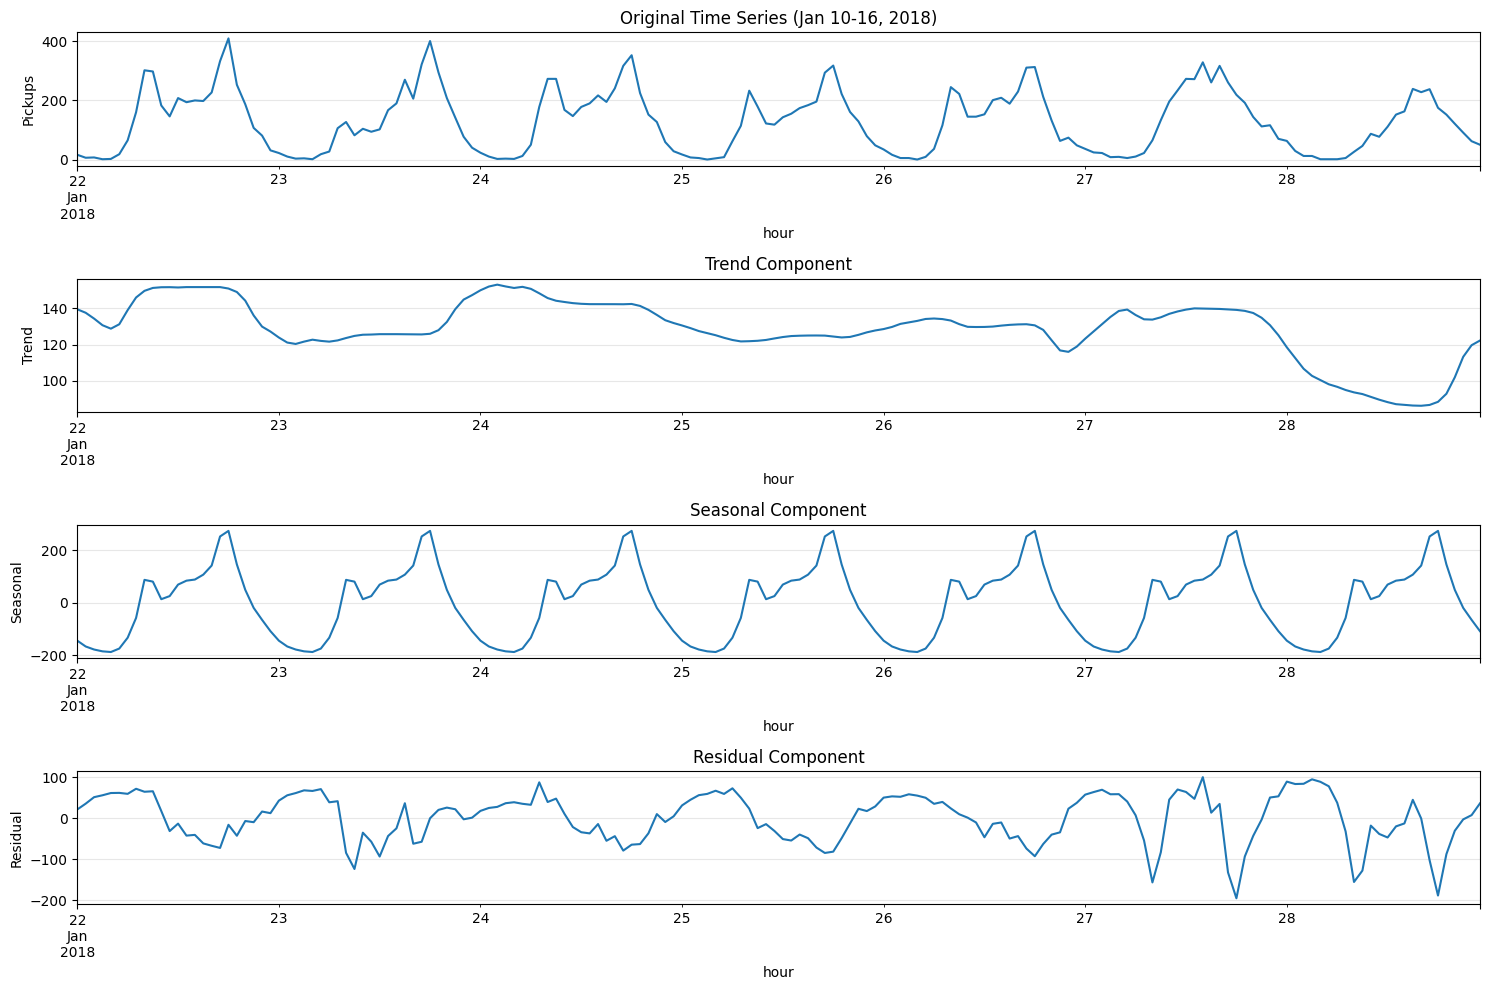

In [11]:
# Perform seasonal decomposition
# Using period=24 for hourly data (24 hours in a day)
# Adjust period if needed based on your data characteristics
decomposition = seasonal_decompose(ts_data, model='additive', period=24)

offset_hours = 21 * 24
period_hours = 7 * 24  # One week
end_idx = offset_hours + period_hours

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

# Original
ts_data[offset_hours:end_idx].plot(ax=axes[0], title='Original Time Series (Jan 10-16, 2018)')
axes[0].set_ylabel('Pickups')
axes[0].grid(True, alpha=0.3)

# Trend
decomposition.trend[offset_hours:end_idx].plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Display overall growth stats (full dataset)
yearly_demand = decomposition.trend.resample('Y').mean()
growth_abs = yearly_demand.iloc[1] - yearly_demand.iloc[0]
growth_pct = (growth_abs / yearly_demand.iloc[0]) * 100

print(f"Average Hourly Trend Demand 2018: {yearly_demand.iloc[0]:.2f}")
print(f"Average Hourly Trend Demand 2019: {yearly_demand.iloc[1]:.2f}")
print(f"Year-over-Year Organic Growth: {growth_pct:.2f}%")

# Seasonal
decomposition.seasonal[offset_hours:end_idx].plot(ax=axes[2], title='Seasonal Component')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# Residual
decomposition.resid[offset_hours:end_idx].plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Original hourly data shape: (17520,)
Monthly aggregated data shape: (24,)

Monthly data preview:
hour
2018-01-31     68150
2018-02-28     83224
2018-03-31     92029
2018-04-30    117681
2018-05-31    169588
2018-06-30    179528
2018-07-31    168827
2018-08-31    179512
2018-09-30    179938
2018-10-31    179998
2018-11-30    115772
2018-12-31     88902
Freq: ME, Name: pickups, dtype: int64

Average Monthly Trend Demand 2018: 138372.67
Average Monthly Trend Demand 2019: 146672.31
Year-over-Year Organic Growth: 6.00%

Average Monthly Trend Demand 2018: 138372.67
Average Monthly Trend Demand 2019: 146672.31
Year-over-Year Organic Growth: 6.00%


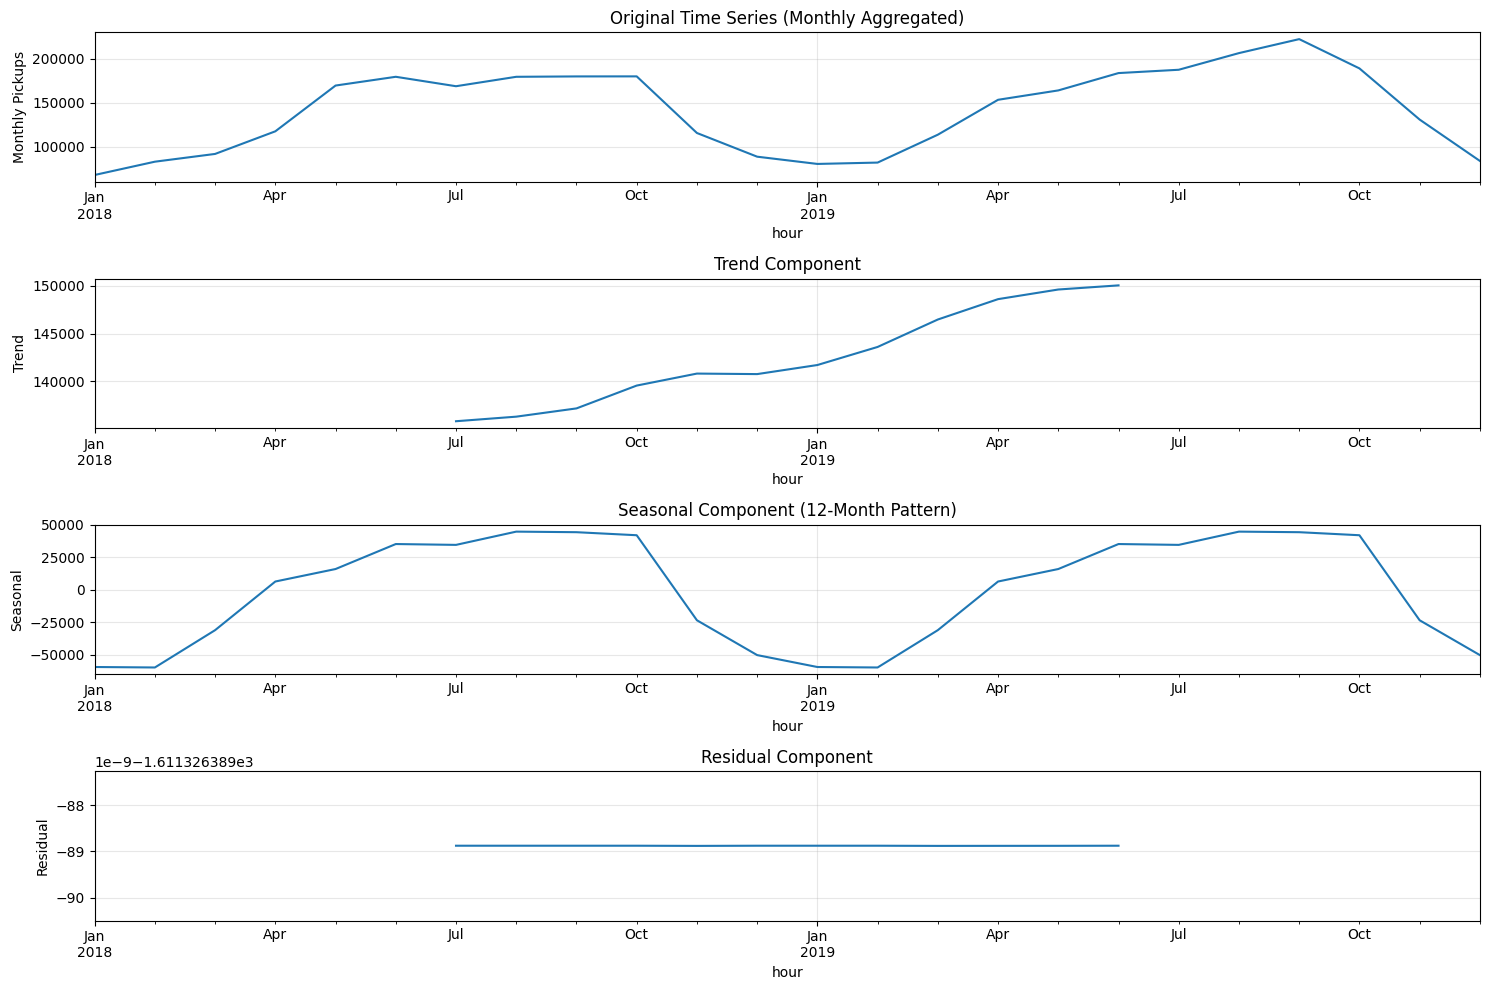

In [12]:
# Aggregate hourly data to monthly totals
ts_data_monthly = ts_data.resample('M').sum()

print(f"Original hourly data shape: {ts_data.shape}")
print(f"Monthly aggregated data shape: {ts_data_monthly.shape}")
print(f"\nMonthly data preview:")
print(ts_data_monthly.head(12))

# Perform seasonal decomposition with period=12 (monthly data, 12 months in a year)
# Use extrapolate_trend='freq' to fill in missing values at the beginning and end
decomposition = seasonal_decompose(ts_data_monthly, model='additive', period=12) #, extrapolate_trend='freq')

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 10))

# Original
ts_data_monthly.plot(ax=axes[0], title='Original Time Series (Monthly Aggregated)')
axes[0].set_ylabel('Monthly Pickups')
axes[0].grid(True, alpha=0.3)

# Trend
decomposition.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Calculate yearly statistics
yearly_demand = decomposition.trend.resample('Y').mean()
growth_abs = yearly_demand.iloc[1] - yearly_demand.iloc[0]
growth_pct = (growth_abs / yearly_demand.iloc[0]) * 100

print(f"\nAverage Monthly Trend Demand 2018: {yearly_demand.iloc[0]:.2f}")
print(f"Average Monthly Trend Demand 2019: {yearly_demand.iloc[1]:.2f}")
print(f"Year-over-Year Organic Growth: {growth_pct:.2f}%")

# Seasonal
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component (12-Month Pattern)')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# Residual
decomposition.resid.plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplot

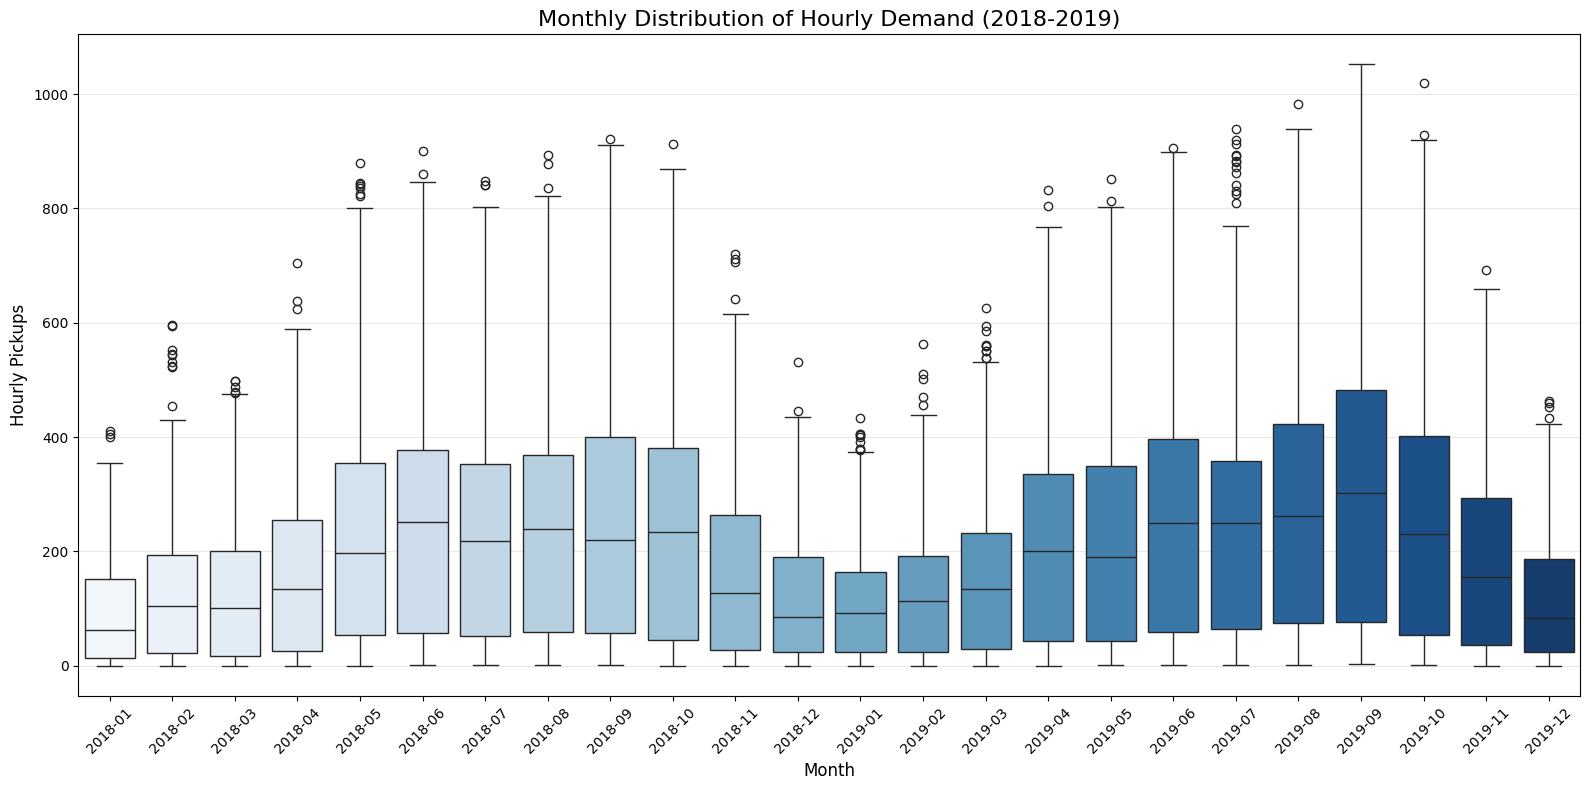

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data for plotting
# Create a DataFrame from the Series if needed
df_box = ts_data.to_frame(name='pickups')

# Extract Year and Month for sorting and labeling
df_box['Year'] = df_box.index.year
df_box['Month'] = df_box.index.month
df_box['YearMonth'] = df_box.index.strftime('%Y-%m') # String for x-axis labels

# 2. Generate the Boxplot
plt.figure(figsize=(16, 8))

# Create boxplot with YearMonth on x-axis
sns.boxplot(x='YearMonth', y='pickups', data=df_box, palette="Blues")

plt.title('Monthly Distribution of Hourly Demand (2018-2019)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Hourly Pickups', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## ARIMA Model Training

Training a dummy ARIMA(0,0,0) model as a baseline.
- Training data: January to October 2018
- Validation data: November and December 2018

In [14]:
# Split data into train (2018 Jan - 2019 Oct) and validation (2019 Nov-Dec)
# This gives more training data while keeping proper temporal ordering
train_ts = ts_data[(ts_data.index.year == 2018) | 
                   ((ts_data.index.year == 2019) & (ts_data.index.month <= 10))]
val_ts = ts_data[(ts_data.index.year == 2019) & (ts_data.index.month >= 11)]

# Count major holidays in each set
print(f"\n{'='*70}")
print("HOLIDAY COVERAGE:")
print(f"{'='*70}")
train_major_2018 = len([d for d in major_holiday_dates if pd.Timestamp(d).year == 2018])
train_major_2019 = len([d for d in major_holiday_dates if pd.Timestamp(d).year == 2019 and pd.Timestamp(d).month <= 10])
val_major_holidays = len([d for d in major_holiday_dates if pd.Timestamp(d).year == 2019 and pd.Timestamp(d).month >= 11])

# Train dummy ARIMA(0,0,0) model on training data
arima = ARIMA(train_ts, order=(0,0,0), enforce_invertibility=False, enforce_stationarity=False)
results = arima.fit()

# Display summary
results.summary()


HOLIDAY COVERAGE:


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                pickups   No. Observations:                16056
Model:                          ARIMA   Log Likelihood             -106490.003
Date:                Fri, 05 Dec 2025   AIC                         212984.007
Time:                        15:03:10   BIC                         212999.374
Sample:                    01-01-2018   HQIC                        212989.088
                         - 10-31-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        199.7068      1.865    107.059      0.000     196.051     203.363
sigma2      3.379e+04    396.093     85.314      0.000     3.3e+04    3.46e+04
===================================================================================
Ljung-Box (L1) (Q):               12746.79   Jarque-Bera (JB):              3836.23
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.63   Skew:                             1.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Dataset final creation

In [22]:
# Split exogenous features into train and validation sets (aligned with train_ts and val_ts)
exog_train = exog_cluster2.loc[train_ts.index]
exog_val = exog_cluster2.loc[val_ts.index]

print(f"Training exog features: {exog_train.shape}")
print(f"Validation exog features: {exog_val.shape}")
print(f"\nTraining exog summary:")
print(exog_train.describe())

print(exog_train.columns)

Training exog features: (16056, 41)
Validation exog features: (1464, 41)

Training exog summary:
               temp  temp_squared    is_raining     rain_lag1    is_weekend  \
count  16056.000000  16056.000000  16056.000000  16056.000000  16056.000000   
mean      13.474707    283.956342      0.048705      0.048705      0.284006   
std       10.119041    268.763915      0.215256      0.215256      0.450954   
min      -18.300000      0.000000      0.000000      0.000000      0.000000   
25%        4.900000     32.490000      0.000000      0.000000      0.000000   
50%       14.500000    210.250000      0.000000      0.000000      0.000000   
75%       22.100000    488.410000      0.000000      0.000000      1.000000   
max       35.500000   1260.250000      1.000000      1.000000      1.000000   

       weekend_hour_0  weekend_hour_1  weekend_hour_2  weekend_hour_3  \
count    16056.000000    16056.000000    16056.000000    16056.000000   
mean         0.011834        0.011834        

## ACF and PACF Analysis

Analyzing autocorrelation and partial autocorrelation to identify potential ARIMA parameters.

hour
2018-01-01 00:00:00    15
2018-01-01 01:00:00    20
2018-01-01 02:00:00     8
2018-01-01 03:00:00     5
2018-01-01 04:00:00     4
Name: pickups, dtype: int64
hour
2018-01-08 00:00:00    2
2018-01-08 01:00:00    4
2018-01-08 02:00:00    0
2018-01-08 03:00:00    1
2018-01-08 04:00:00    1
Name: pickups, dtype: int64


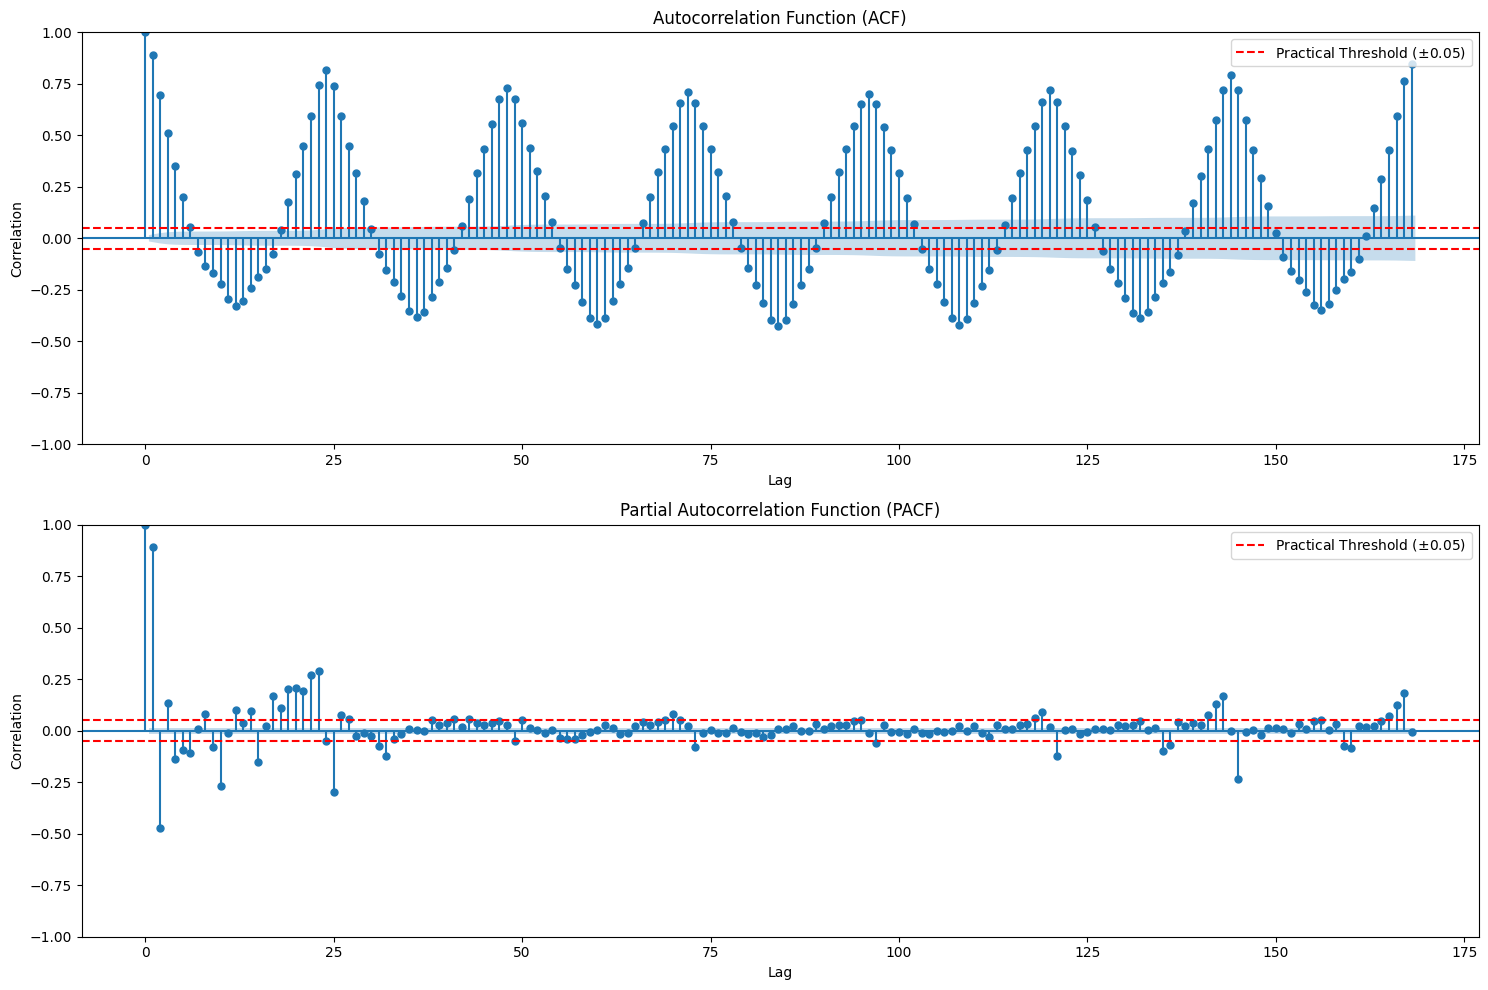

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF (Autocorrelation Function)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

offset_hours = 21 * 24
period_hours = 7 * 24  # One week
nr_lags = period_hours

print(train_ts.head())
print(train_ts[period_hours:].head())

plot_acf(train_ts[period_hours:], lags=nr_lags, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')
# Add lines for practical significance threshold (+/- 0.05)
axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Practical Threshold ($\pm 0.05$)')
axes[0].axhline(y=-0.05, color='red', linestyle='--', linewidth=1.5)
axes[0].legend(loc='upper right')

# Plot PACF (Partial Autocorrelation Function)
plot_pacf(train_ts[period_hours:], lags=nr_lags, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Correlation')

# Add lines for practical significance threshold (+/- 0.05)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Practical Threshold ($\pm 0.05$)')
axes[1].axhline(y=-0.05, color='red', linestyle='--', linewidth=1.5)
axes[1].legend(loc='upper right')

plt.tight_layout() 
plt.show()

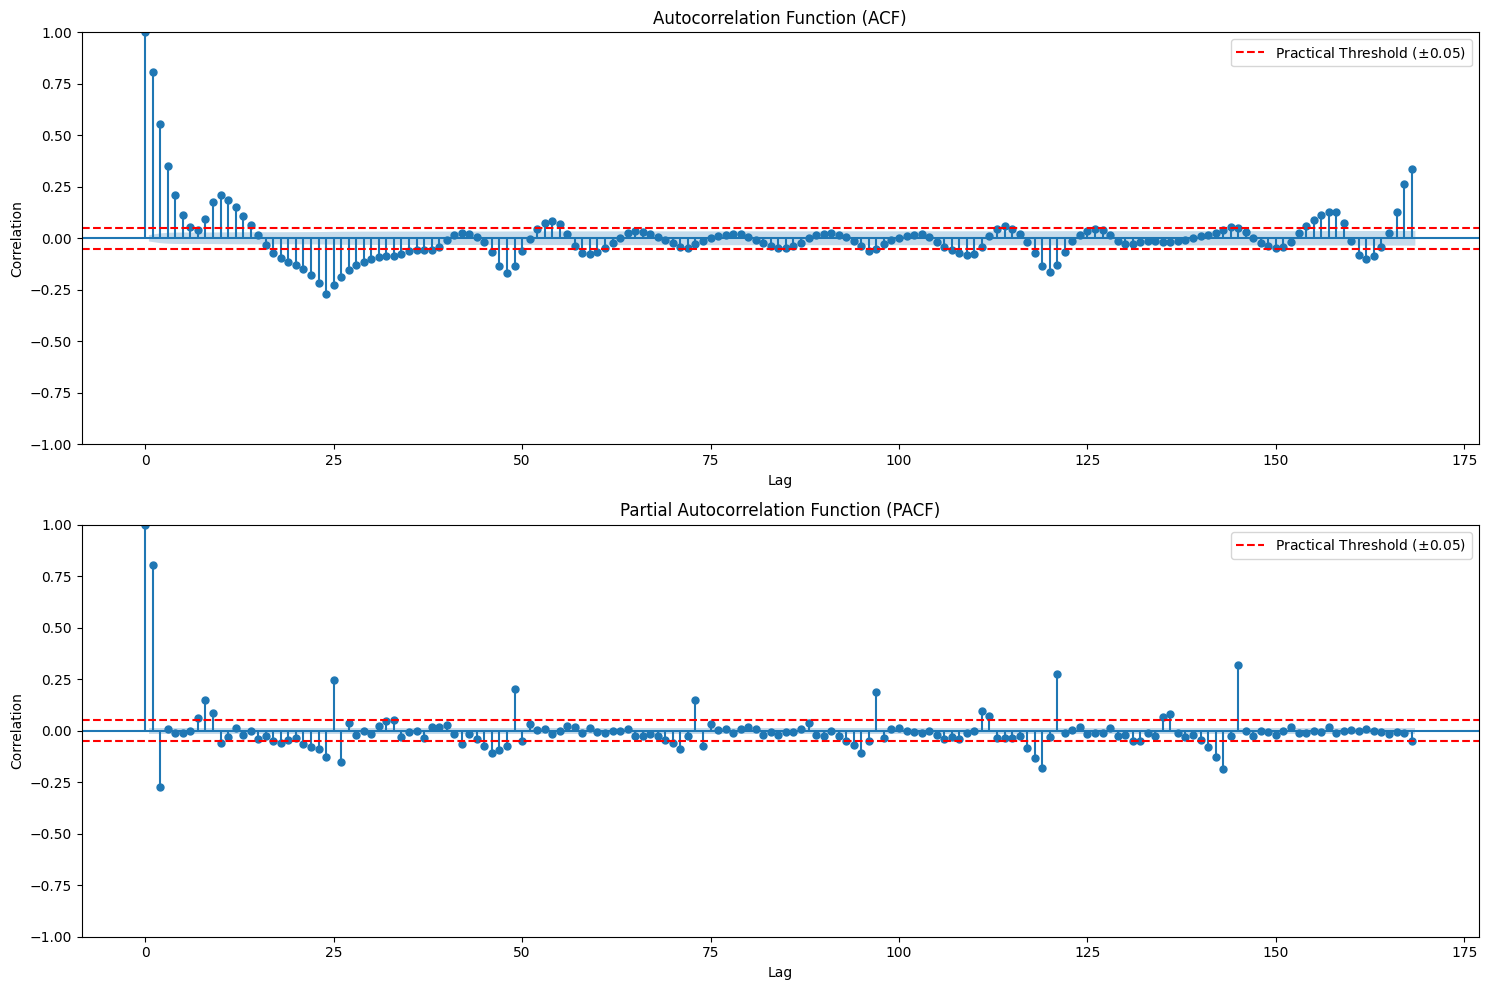

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_ts_diff = train_ts.diff(24).dropna()

# Plot ACF (Autocorrelation Function)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(train_ts_diff[period_hours:], lags=nr_lags, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')

# Add lines for practical significance threshold (+/- 0.05)
axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Practical Threshold ($\pm 0.05$)')
axes[0].axhline(y=-0.05, color='red', linestyle='--', linewidth=1.5)
axes[0].legend(loc='upper right')

# Plot PACF (Partial Autocorrelation Function)
plot_pacf(train_ts_diff[period_hours:], lags=nr_lags, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Correlation')

# Add lines for practical significance threshold (+/- 0.05)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Practical Threshold ($\pm 0.05$)')
axes[1].axhline(y=-0.05, color='red', linestyle='--', linewidth=1.5)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Train MODELS (SARIMAX)



In [26]:
import os
import pickle
import time
from datetime import datetime

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Define all SARIMA combinations to test
sarima_combinations = [
    # ((2, 0, 0), (0, 1, 1, 24)),
    ((2, 0, 0), (1, 1, 1, 24)),
    ((2, 1, 0), (0, 1, 1, 24)),
    ((2, 1, 0), (1, 1, 1, 24)),
    # ((2, 0, 1), (0, 1, 1, 24)),
    # ((2, 0, 1), (1, 1, 1, 24)),
    # ((3, 1, 2), (0, 1, 1, 24)),
    # ((3, 1, 2), (1, 1, 1, 24))
]

# Store results for tracking
model_results = []

print(f"{'='*80}")
print(f"TRAINING {len(sarima_combinations)} SARIMA MODELS")
print(f"{'='*80}\n")

# Train and save each model
for i, (order, seasonal_order) in enumerate(sarima_combinations, 1):
    p, d, q = order
    P, D, Q, s = seasonal_order
    
    # Create model name
    model_name = f"sarimax_2_years_({p},{d},{q})({P},{D},{Q},{s})"
    model_path = f"models/{model_name}.pkl"
    
    print(f"[{i}/{len(sarima_combinations)}] Training {model_name}")
    print(f"  Order: {order}, Seasonal: {seasonal_order}")
    
    # Start timer
    start_time = time.time()
    
    try:
        # Train SARIMA model
        model = SARIMAX(
            train_ts,
            exog=exog_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_invertibility=False,
            enforce_stationarity=False
        )
        
        fitted_model = model.fit(disp=False)
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Save model
        with open(model_path, 'wb') as f:
            pickle.dump(fitted_model, f)
        
        # Store results
        model_results.append({
            'model_name': model_name,
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': fitted_model.aic,
            'bic': fitted_model.bic,
            'training_time': training_time,
            'status': 'success'
        })
        
        print(f"  ✓ Training completed in {training_time:.2f}s")
        print(f"  ✓ AIC: {fitted_model.aic:.2f}, BIC: {fitted_model.bic:.2f}")
        print(f"  ✓ Model saved to: {model_path}\n")
        
    except Exception as e:
        training_time = time.time() - start_time
        print(f"  ✗ Training failed after {training_time:.2f}s")
        print(f"  ✗ Error: {str(e)}\n")
        
        model_results.append({
            'model_name': model_name,
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': None,
            'bic': None,
            'training_time': training_time,
            'status': 'failed',
            'error': str(e)
        })

print(f"{'='*80}")
print(f"TRAINING SUMMARY")
print(f"{'='*80}")
successful = sum(1 for r in model_results if r['status'] == 'success')
failed = sum(1 for r in model_results if r['status'] == 'failed')
total_time = sum(r['training_time'] for r in model_results)

print(f"Total models: {len(model_results)}")
print(f"Successful: {successful}")
print(f"Failed: {failed}")
print(f"Total training time: {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"\nAll models saved to: models/")


TRAINING 3 SARIMA MODELS

[1/3] Training sarimax_2_years_(2,0,0)(1,1,1,24)
  Order: (2, 0, 0), Seasonal: (1, 1, 1, 24)
  ✓ Training completed in 931.10s
  ✓ AIC: 164658.94, BIC: 165012.25
  ✓ Model saved to: models/sarimax_2_years_(2,0,0)(1,1,1,24).pkl

[2/3] Training sarimax_2_years_(2,1,0)(0,1,1,24)
  Order: (2, 1, 0), Seasonal: (0, 1, 1, 24)
  ✓ Training completed in 931.10s
  ✓ AIC: 164658.94, BIC: 165012.25
  ✓ Model saved to: models/sarimax_2_years_(2,0,0)(1,1,1,24).pkl

[2/3] Training sarimax_2_years_(2,1,0)(0,1,1,24)
  Order: (2, 1, 0), Seasonal: (0, 1, 1, 24)
  ✓ Training completed in 870.87s
  ✓ AIC: 166339.74, BIC: 166685.37
  ✓ Model saved to: models/sarimax_2_years_(2,1,0)(0,1,1,24).pkl

[3/3] Training sarimax_2_years_(2,1,0)(1,1,1,24)
  Order: (2, 1, 0), Seasonal: (1, 1, 1, 24)
  ✓ Training completed in 870.87s
  ✓ AIC: 166339.74, BIC: 166685.37
  ✓ Model saved to: models/sarimax_2_years_(2,1,0)(0,1,1,24).pkl

[3/3] Training sarimax_2_years_(2,1,0)(1,1,1,24)
  Order: (2, 

## Model Evaluation and Comparison

In [28]:
import os
import pickle
import pandas as pd
from glob import glob

# Load all models from the models folder
models_folder = 'models'
model_files = glob(f'{models_folder}/*.pkl')

print(f"{'='*80}")
print(f"MODEL EVALUATION - Found {len(model_files)} models")
print(f"{'='*80}\n")

# Store evaluation results
evaluation_results = []

for model_file in sorted(model_files):
    model_name = os.path.basename(model_file).replace('.pkl', '')
    
    try:
        # Load the model
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
        
        # Extract model parameters from filename
        # Format: sarima_2_years_(p,d,q)(P,D,Q,s).pkl
        params_str = model_name.replace('sarima_2_years_', '')
        
        # Get summary statistics
        summary_data = {
            'model_name': model_name,
            'aic': model.aic,
            'bic': model.bic,
            'log_likelihood': model.llf,
            'n_observations': model.nobs,
            'parameters': params_str
        }
        
        evaluation_results.append(summary_data)
        
        print(f"✓ {model_name}")
        print(f"  AIC: {model.aic:.2f} | BIC: {model.bic:.2f} | Log-Likelihood: {model.llf:.2f}")
        
    except Exception as e:
        print(f"✗ Failed to load {model_name}: {str(e)}")

# Create comparison DataFrame
comparison_df = pd.DataFrame(evaluation_results)

if len(comparison_df) > 0:
    # Sort by AIC (lower is better)
    comparison_df = comparison_df.sort_values('aic')
    
    print(f"\n{'='*80}")
    print(f"MODEL COMPARISON (Sorted by AIC)")
    print(f"{'='*80}\n")
    
    # Display formatted table
    print(comparison_df.to_string(index=False))
    
    # Highlight best models
    print(f"\n{'='*80}")
    print(f"BEST MODELS")
    print(f"{'='*80}")
    
    best_aic = comparison_df.iloc[0]
    best_bic = comparison_df.sort_values('bic').iloc[0]
    
    print(f"\nBest by AIC:")
    print(f"  Model: {best_aic['model_name']}")
    print(f"  AIC: {best_aic['aic']:.2f}")
    print(f"  BIC: {best_aic['bic']:.2f}")
    
    print(f"\nBest by BIC:")
    print(f"  Model: {best_bic['model_name']}")
    print(f"  AIC: {best_bic['aic']:.2f}")
    print(f"  BIC: {best_bic['bic']:.2f}")
    
    # Calculate differences from best
    comparison_df['aic_diff'] = comparison_df['aic'] - comparison_df['aic'].min()
    comparison_df['bic_diff'] = comparison_df['bic'] - comparison_df['bic'].min()
    
    print(f"\n{'='*80}")
    print(f"RELATIVE PERFORMANCE (Difference from Best)")
    print(f"{'='*80}\n")
    print(comparison_df[['model_name', 'aic_diff', 'bic_diff']].to_string(index=False))
    
else:
    print("\nNo models found to evaluate.")

MODEL EVALUATION - Found 16 models

✓ sarima_2_years_(2,0,0)(0,1,1,24)
  AIC: 171420.59 | BIC: 171451.32 | Log-Likelihood: -85706.30
✓ sarima_2_years_(2,0,0)(0,1,1,24)
  AIC: 171420.59 | BIC: 171451.32 | Log-Likelihood: -85706.30
✓ sarima_2_years_(2,0,0)(1,1,1,24)
  AIC: 170789.70 | BIC: 170828.11 | Log-Likelihood: -85389.85
✓ sarima_2_years_(2,0,0)(1,1,1,24)
  AIC: 170789.70 | BIC: 170828.11 | Log-Likelihood: -85389.85
✓ sarima_2_years_(2,0,1)(0,1,1,24)
  AIC: 171365.54 | BIC: 171403.94 | Log-Likelihood: -85677.77
✓ sarima_2_years_(2,0,1)(0,1,1,24)
  AIC: 171365.54 | BIC: 171403.94 | Log-Likelihood: -85677.77
✓ sarima_2_years_(2,0,1)(1,1,1,24)
  AIC: 170766.80 | BIC: 170812.88 | Log-Likelihood: -85377.40
✓ sarima_2_years_(2,0,1)(1,1,1,24)
  AIC: 170766.80 | BIC: 170812.88 | Log-Likelihood: -85377.40
✓ sarima_2_years_(2,1,0)(0,1,1,24)
  AIC: 173421.91 | BIC: 173452.64 | Log-Likelihood: -86706.96
✓ sarima_2_years_(2,1,0)(0,1,1,24)
  AIC: 173421.91 | BIC: 173452.64 | Log-Likelihood: -867

## Forecast Evaluation for All Models

In [32]:
import os
import pickle
import numpy as np
import pandas as pd
from glob import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# Load all models from the models folder (both SARIMA and SARIMAX)
models_folder = 'models'
model_files = glob(f'{models_folder}/*sarima*.pkl')  # Matches both sarima and sarimax

# Get the first day of validation set for forecasting
first_day = val_ts.iloc[:24]
first_day_exog = exog_val.iloc[:24]
first_day_date = first_day.index[0].date()
actual_values = first_day.values

print(f"{'='*80}")
print(f"FORECASTING FIRST DAY OF VALIDATION SET: {first_day_date}")
print(f"{'='*80}")
print(f"Time range: {first_day.index[0]} to {first_day.index[-1]}")
print(f"Found {len(model_files)} models to evaluate\n")

# Store forecast results
forecast_results = []

# Evaluate each model
for i, model_file in enumerate(sorted(model_files), 1):
    model_name = os.path.basename(model_file).replace('.pkl', '')
    
    print(f"[{i}/{len(model_files)}] Evaluating {model_name}")
    
    start_time = time.time()
    
    try:
        # Load the model
        with open(model_file, 'rb') as f:
            fitted_model = pickle.load(f)
        
        # Check if model uses exogenous features
        # Models have exog if they were fitted with exog parameters
        has_exog = hasattr(fitted_model.model, 'exog') and fitted_model.model.exog is not None
        
        # Forecast 24 hours (with or without exogenous features)
        if has_exog:
            forecast = fitted_model.forecast(steps=24, exog=first_day_exog)
        else:
            forecast = fitted_model.forecast(steps=24)
        
        predicted_values = forecast.values
        
        # Calculate metrics
        mse = mean_squared_error(actual_values, predicted_values)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actual_values, predicted_values)
        mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100
        r2 = r2_score(actual_values, predicted_values)
        
        # Calculate additional metrics
        mean_actual = actual_values.mean()
        mean_predicted = predicted_values.mean()
        max_error = np.max(np.abs(actual_values - predicted_values))
        
        forecast_time = time.time() - start_time
        
        # Store results
        forecast_results.append({
            'model_name': model_name,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'r2': r2,
            'mse': mse,
            'mean_actual': mean_actual,
            'mean_predicted': mean_predicted,
            'max_error': max_error,
            'forecast_time': forecast_time,
            'status': 'success'
        })
        
        print(f"  ✓ RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")
        print(f"  ✓ Forecast completed in {forecast_time:.3f}s\n")
        
    except Exception as e:
        forecast_time = time.time() - start_time
        print(f"  ✗ Forecast failed after {forecast_time:.3f}s")
        print(f"  ✗ Error: {str(e)}\n")
        
        forecast_results.append({
            'model_name': model_name,
            'rmse': None,
            'mae': None,
            'mape': None,
            'r2': None,
            'mse': None,
            'mean_actual': None,
            'mean_predicted': None,
            'max_error': None,
            'forecast_time': forecast_time,
            'status': 'failed',
            'error': str(e)
        })

print(f"{'='*80}")
print(f"FORECAST SUMMARY")
print(f"{'='*80}")
successful = sum(1 for r in forecast_results if r['status'] == 'success')
failed = sum(1 for r in forecast_results if r['status'] == 'failed')
total_forecast_time = sum(r['forecast_time'] for r in forecast_results)

print(f"Total models evaluated: {len(forecast_results)}")
print(f"Successful: {successful}")
print(f"Failed: {failed}")
print(f"Total forecast time: {total_forecast_time:.2f}s")

# Save results to CSV
forecast_df = pd.DataFrame(forecast_results)
forecast_df.to_csv('models/forecast_evaluation_results.csv', index=False)
print(f"\n✓ Forecast results saved to: models/forecast_evaluation_results.csv")


FORECASTING FIRST DAY OF VALIDATION SET: 2019-11-01
Time range: 2019-11-01 00:00:00 to 2019-11-01 23:00:00
Found 16 models to evaluate

[1/16] Evaluating sarima_2_years_(2,0,0)(0,1,1,24)
  ✓ RMSE: 33.12 | MAE: 25.89 | MAPE: 42.47% | R²: 0.9703
  ✓ Forecast completed in 2.363s

[2/16] Evaluating sarima_2_years_(2,0,0)(1,1,1,24)
  ✓ RMSE: 33.12 | MAE: 25.89 | MAPE: 42.47% | R²: 0.9703
  ✓ Forecast completed in 2.363s

[2/16] Evaluating sarima_2_years_(2,0,0)(1,1,1,24)
  ✓ RMSE: 42.15 | MAE: 33.79 | MAPE: 40.36% | R²: 0.9520
  ✓ Forecast completed in 2.933s

[3/16] Evaluating sarima_2_years_(2,0,1)(0,1,1,24)
  ✓ RMSE: 42.15 | MAE: 33.79 | MAPE: 40.36% | R²: 0.9520
  ✓ Forecast completed in 2.933s

[3/16] Evaluating sarima_2_years_(2,0,1)(0,1,1,24)
  ✓ RMSE: 34.21 | MAE: 27.09 | MAPE: 49.70% | R²: 0.9683
  ✓ Forecast completed in 2.181s

[4/16] Evaluating sarima_2_years_(2,0,1)(1,1,1,24)
  ✓ RMSE: 34.21 | MAE: 27.09 | MAPE: 49.70% | R²: 0.9683
  ✓ Forecast completed in 2.181s

[4/16] Evalu

## Compare Forecast Performance

FORECAST PERFORMANCE COMPARISON

Performance Metrics (Sorted by RMSE):
                       model_name       rmse       mae       mape       r2  forecast_time
 sarima_2_years_(2,0,0)(0,1,1,24)  33.115280 25.890550  42.466032 0.970343       2.363464
 sarima_2_years_(2,0,1)(0,1,1,24)  34.212093 27.086834  49.700246 0.968346       2.180645
 sarima_2_years_(3,1,2)(0,1,1,24)  39.275313 33.496756  39.286152 0.958284       2.297026
 sarima_2_years_(2,0,0)(1,1,1,24)  42.149591 33.793401  40.359440 0.951954       2.932985
 sarima_2_years_(2,0,1)(1,1,1,24)  42.358827 34.216629  45.281043 0.951476       2.051726
sarimax_2_years_(2,0,0)(1,1,1,24)  43.044384 35.697876  44.279778 0.949893       2.478218
sarimax_2_years_(3,1,2)(0,1,1,24)  44.747009 38.146365  56.092841 0.945850       2.355524
sarimax_2_years_(2,0,0)(0,1,1,24)  45.258042 38.120279  50.647403 0.944606       2.271892
sarimax_2_years_(3,1,2)(1,1,1,24)  45.360662 38.932834  61.698439 0.944355       2.366205
sarimax_2_years_(2,0,1)(0,1,1

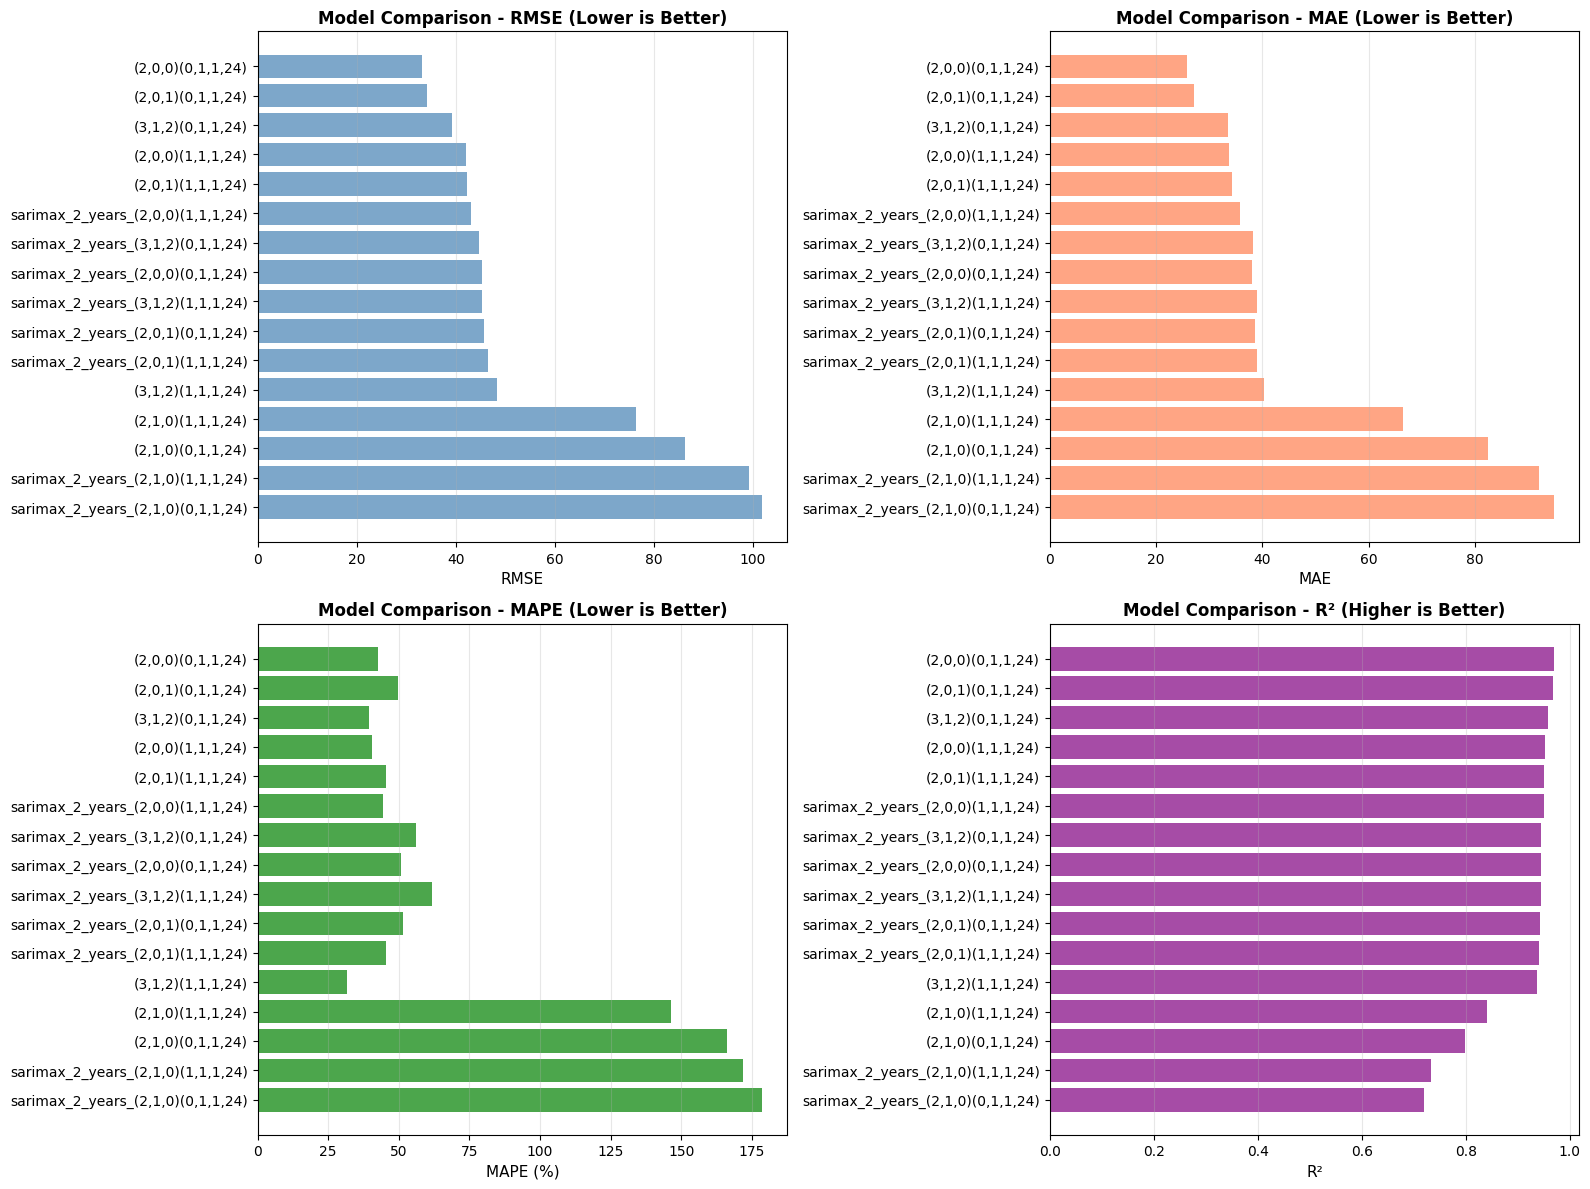


✓ Comparison visualization saved to: models/forecast_performance_comparison.png

PERFORMANCE STATISTICS

RMSE: min=33.12, max=101.87, mean=54.62
MAE:  min=25.89, max=94.87, mean=47.42
MAPE: min=31.64%, max=178.53%, mean=76.33%
R²:   min=0.7193, max=0.9703, mean=0.9063


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load forecast results
forecast_df = pd.DataFrame(forecast_results)

# Filter only successful forecasts
successful_forecasts = forecast_df[forecast_df['status'] == 'success'].copy()

if len(successful_forecasts) > 0:
    print(f"{'='*80}")
    print(f"FORECAST PERFORMANCE COMPARISON")
    print(f"{'='*80}\n")
    
    # Sort by RMSE (lower is better)
    successful_forecasts_sorted = successful_forecasts.sort_values('rmse')
    
    # Display summary table
    print("Performance Metrics (Sorted by RMSE):")
    print(f"{'='*80}")
    display_cols = ['model_name', 'rmse', 'mae', 'mape', 'r2', 'forecast_time']
    print(successful_forecasts_sorted[display_cols].to_string(index=False))
    
    # Identify best models by different metrics
    print(f"\n{'='*80}")
    print(f"BEST MODELS BY METRIC")
    print(f"{'='*80}")
    
    best_rmse = successful_forecasts_sorted.iloc[0]
    best_mae = successful_forecasts.sort_values('mae').iloc[0]
    best_mape = successful_forecasts.sort_values('mape').iloc[0]
    best_r2 = successful_forecasts.sort_values('r2', ascending=False).iloc[0]
    
    print(f"\nBest by RMSE:")
    print(f"  Model: {best_rmse['model_name']}")
    print(f"  RMSE: {best_rmse['rmse']:.2f} | MAE: {best_rmse['mae']:.2f} | MAPE: {best_rmse['mape']:.2f}% | R²: {best_rmse['r2']:.4f}")
    
    print(f"\nBest by MAE:")
    print(f"  Model: {best_mae['model_name']}")
    print(f"  RMSE: {best_mae['rmse']:.2f} | MAE: {best_mae['mae']:.2f} | MAPE: {best_mae['mape']:.2f}% | R²: {best_mae['r2']:.4f}")
    
    print(f"\nBest by MAPE:")
    print(f"  Model: {best_mape['model_name']}")
    print(f"  RMSE: {best_mape['rmse']:.2f} | MAE: {best_mape['mae']:.2f} | MAPE: {best_mape['mape']:.2f}% | R²: {best_mape['r2']:.4f}")
    
    print(f"\nBest by R²:")
    print(f"  Model: {best_r2['model_name']}")
    print(f"  RMSE: {best_r2['rmse']:.2f} | MAE: {best_r2['mae']:.2f} | MAPE: {best_r2['mape']:.2f}% | R²: {best_r2['r2']:.4f}")
    
    # Calculate relative performance
    successful_forecasts_sorted['rmse_diff'] = successful_forecasts_sorted['rmse'] - successful_forecasts_sorted['rmse'].min()
    successful_forecasts_sorted['mae_diff'] = successful_forecasts_sorted['mae'] - successful_forecasts_sorted['mae'].min()
    successful_forecasts_sorted['mape_diff'] = successful_forecasts_sorted['mape'] - successful_forecasts_sorted['mape'].min()
    
    print(f"\n{'='*80}")
    print(f"RELATIVE PERFORMANCE (Difference from Best)")
    print(f"{'='*80}\n")
    print(successful_forecasts_sorted[['model_name', 'rmse_diff', 'mae_diff', 'mape_diff']].to_string(index=False))
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: RMSE comparison
    models_short = [name.replace('sarima_2_years_', '') for name in successful_forecasts_sorted['model_name']]
    axes[0, 0].barh(models_short, successful_forecasts_sorted['rmse'], color='steelblue', alpha=0.7)
    axes[0, 0].set_xlabel('RMSE', fontsize=11)
    axes[0, 0].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    axes[0, 0].invert_yaxis()
    
    # Plot 2: MAE comparison
    axes[0, 1].barh(models_short, successful_forecasts_sorted['mae'], color='coral', alpha=0.7)
    axes[0, 1].set_xlabel('MAE', fontsize=11)
    axes[0, 1].set_title('Model Comparison - MAE (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    axes[0, 1].invert_yaxis()
    
    # Plot 3: MAPE comparison
    axes[1, 0].barh(models_short, successful_forecasts_sorted['mape'], color='green', alpha=0.7)
    axes[1, 0].set_xlabel('MAPE (%)', fontsize=11)
    axes[1, 0].set_title('Model Comparison - MAPE (Lower is Better)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    axes[1, 0].invert_yaxis()
    
    # Plot 4: R² comparison
    r2_sorted = successful_forecasts.sort_values('r2', ascending=False)
    models_short_r2 = [name.replace('sarima_2_years_', '') for name in r2_sorted['model_name']]
    axes[1, 1].barh(models_short_r2, r2_sorted['r2'], color='purple', alpha=0.7)
    axes[1, 1].set_xlabel('R²', fontsize=11)
    axes[1, 1].set_title('Model Comparison - R² (Higher is Better)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    axes[1, 1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('models/forecast_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Comparison visualization saved to: models/forecast_performance_comparison.png")
    
    # Summary statistics
    print(f"\n{'='*80}")
    print(f"PERFORMANCE STATISTICS")
    print(f"{'='*80}")
    print(f"\nRMSE: min={successful_forecasts['rmse'].min():.2f}, max={successful_forecasts['rmse'].max():.2f}, mean={successful_forecasts['rmse'].mean():.2f}")
    print(f"MAE:  min={successful_forecasts['mae'].min():.2f}, max={successful_forecasts['mae'].max():.2f}, mean={successful_forecasts['mae'].mean():.2f}")
    print(f"MAPE: min={successful_forecasts['mape'].min():.2f}%, max={successful_forecasts['mape'].max():.2f}%, mean={successful_forecasts['mape'].mean():.2f}%")
    print(f"R²:   min={successful_forecasts['r2'].min():.4f}, max={successful_forecasts['r2'].max():.4f}, mean={successful_forecasts['r2'].mean():.4f}")
    
else:
    print("No successful forecasts to compare.")


## Rolling Forecast - Walk-Forward Validation

In [16]:
import os
import pickle
import numpy as np
import pandas as pd
from glob import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from datetime import datetime

# Load all models from the models folder (both SARIMA and SARIMAX)
models_folder = 'models'
# model_files = glob(f'{models_folder}/*sarima*.pkl')  # Matches both sarima and sarimax
model_files = glob(f'{models_folder}/sarima*.pkl')  # Matches both sarima and sarimax

# Get November 2019 validation data
val_nov = val_ts[(val_ts.index.year == 2019) & (val_ts.index.month == 11)]
exog_nov = exog_val[(exog_val.index.year == 2019) & (exog_val.index.month == 11)]

# Calculate number of days in November
num_days = len(val_nov) // 24
print(f"{'='*80}")
print(f"ROLLING FORECAST - WALK-FORWARD VALIDATION")
print(f"{'='*80}")
print(f"Validation period: November 2019")
print(f"Total hours: {len(val_nov)}")
print(f"Total days: {num_days}")
print(f"Models to evaluate: {len(model_files)}\n")

# Store all results
all_rolling_results = []

# Evaluate each model
for model_idx, model_file in enumerate(sorted(model_files), 1):
    model_name = os.path.basename(model_file).replace('.pkl', '')
    
    print(f"\n{'='*80}")
    print(f"[{model_idx}/{len(model_files)}] {model_name}")
    print(f"{'='*80}")
    
    start_time = time.time()
    
    try:
        # Load the model
        with open(model_file, 'rb') as f:
            base_model = pickle.load(f)
        
        # Check if model uses exogenous features
        has_exog = hasattr(base_model.model, 'exog') and base_model.model.exog is not None
        print("Model uses exog features: ", has_exog)
        
        # Create a copy for rolling forecast
        current_model = base_model
        
        # Store daily results for this model
        daily_results = []
        all_actual = []
        all_predicted = []
        
        # Rolling forecast for each day
        for day in range(num_days):
            day_start_idx = day * 24
            day_end_idx = day_start_idx + 24
            
            # Get actual values and exog for this day
            day_actual = val_nov.iloc[day_start_idx:day_end_idx]
            day_exog = exog_nov.iloc[day_start_idx:day_end_idx]
            day_date = day_actual.index[0].date()
            
            # Forecast next 24 hours (with or without exogenous features)
            if has_exog:
                forecast = current_model.forecast(steps=24, exog=day_exog)
            else:
                forecast = current_model.forecast(steps=24)
            
            actual_vals = day_actual.values
            predicted_vals = forecast.values
            
            # Calculate daily metrics
            day_mse = mean_squared_error(actual_vals, predicted_vals)
            day_rmse = np.sqrt(day_mse)
            day_mae = mean_absolute_error(actual_vals, predicted_vals)
            day_mape = np.mean(np.abs((actual_vals - predicted_vals) / actual_vals)) * 100
            day_r2 = r2_score(actual_vals, predicted_vals)
            
            # Store daily results
            daily_results.append({
                'model_name': model_name,
                'day': day + 1,
                'date': day_date,
                'rmse': day_rmse,
                'mae': day_mae,
                'mape': day_mape,
                'r2': day_r2,
                'mean_actual': actual_vals.mean(),
                'mean_predicted': predicted_vals.mean()
            })
            
            # Accumulate all predictions
            all_actual.extend(actual_vals)
            all_predicted.extend(predicted_vals)
            if has_exog:
                current_model = current_model.append(day_actual, exog=day_exog, refit=False)
            else:
                current_model = current_model.append(day_actual, refit=False)
            
            print(f"  Day {day+1:2d} ({day_date}): RMSE={day_rmse:.2f}, MAE={day_mae:.2f}, MAPE={day_mape:.2f}%, R²={day_r2:.4f}")
        
        # Calculate overall metrics for the entire period
        all_actual = np.array(all_actual)
        all_predicted = np.array(all_predicted)
        
        overall_mse = mean_squared_error(all_actual, all_predicted)
        overall_rmse = np.sqrt(overall_mse)
        overall_mae = mean_absolute_error(all_actual, all_predicted)
        overall_mape = np.mean(np.abs((all_actual - all_predicted) / all_actual)) * 100
        overall_r2 = r2_score(all_actual, all_predicted)
        
        total_time = time.time() - start_time
        
        # Store overall results
        overall_result = {
            'model_name': model_name,
            'overall_rmse': overall_rmse,
            'overall_mae': overall_mae,
            'overall_mape': overall_mape,
            'overall_r2': overall_r2,
            'num_days': num_days,
            'total_hours': len(all_actual),
            'total_time': total_time,
            'status': 'success'
        }
        
        all_rolling_results.append(overall_result)
        
        # Add daily results to accumulator
        for daily_res in daily_results:
            all_rolling_results.append(daily_res)
        
        print(f"\n  ✓ Overall Performance:")
        print(f"    RMSE: {overall_rmse:.2f} | MAE: {overall_mae:.2f} | MAPE: {overall_mape:.2f}% | R²: {overall_r2:.4f}")
        print(f"  ✓ Completed in {total_time:.2f}s")
        
    except Exception as e:
        total_time = time.time() - start_time
        print(f"\n  ✗ Rolling forecast failed after {total_time:.2f}s")
        print(f"  ✗ Error: {str(e)}")
        
        all_rolling_results.append({
            'model_name': model_name,
            'overall_rmse': None,
            'overall_mae': None,
            'overall_mape': None,
            'overall_r2': None,
            'num_days': num_days,
            'total_hours': None,
            'total_time': total_time,
            'status': 'failed',
            'error': str(e)
        })

print(f"\n{'='*80}")
print(f"ROLLING FORECAST SUMMARY")
print(f"{'='*80}")
successful_models = sum(1 for r in all_rolling_results if r.get('status') == 'success')
print(f"Models evaluated: {len(model_files)}")
print(f"Successful: {successful_models}")
print(f"Failed: {len(model_files) - successful_models}")

# Save results to CSV
rolling_results_df = pd.DataFrame(all_rolling_results)

rolling_results_df.to_csv('models/rolling_forecast_results.csv', index=False)

print(f"\n✓ Rolling forecast results saved to: models/rolling_forecast_results.csv")


ROLLING FORECAST - WALK-FORWARD VALIDATION
Validation period: November 2019
Total hours: 720
Total days: 30
Models to evaluate: 16


[1/16] sarima_2_years_(2,0,0)(0,1,1,24)
Model uses exog features:  False
Model uses exog features:  False
  Day  1 (2019-11-01): RMSE=33.12, MAE=25.89, MAPE=42.47%, R²=0.9703
  Day  1 (2019-11-01): RMSE=33.12, MAE=25.89, MAPE=42.47%, R²=0.9703
  Day  2 (2019-11-02): RMSE=112.31, MAE=86.81, MAPE=68.79%, R²=0.5775
  Day  2 (2019-11-02): RMSE=112.31, MAE=86.81, MAPE=68.79%, R²=0.5775
  Day  3 (2019-11-03): RMSE=124.50, MAE=86.32, MAPE=130.10%, R²=0.1960
  Day  3 (2019-11-03): RMSE=124.50, MAE=86.32, MAPE=130.10%, R²=0.1960
  Day  4 (2019-11-04): RMSE=39.16, MAE=29.84, MAPE=34.95%, R²=0.9580
  Day  4 (2019-11-04): RMSE=39.16, MAE=29.84, MAPE=34.95%, R²=0.9580
  Day  5 (2019-11-05): RMSE=60.29, MAE=42.49, MAPE=25.03%, R²=0.9093
  Day  5 (2019-11-05): RMSE=60.29, MAE=42.49, MAPE=25.03%, R²=0.9093
  Day  6 (2019-11-06): RMSE=49.12, MAE=29.08, MAPE=19.02%, R²=0.9

## Evaluate Rolling Forecast Results

ROLLING FORECAST EVALUATION - NOVEMBER 2019

Overall Performance Across All Days (Sorted by RMSE):
                       model_name  overall_rmse  overall_mae  overall_mape  overall_r2  total_time
sarimax_2_years_(2,0,0)(1,1,1,24)     71.852199    46.006957           inf    0.780157   75.282886
sarimax_2_years_(2,0,1)(1,1,1,24)     72.075508    47.660221           inf    0.778789   75.434830
sarimax_2_years_(2,0,1)(0,1,1,24)     72.549704    47.929476           inf    0.775868   79.049767
sarimax_2_years_(2,0,0)(0,1,1,24)     72.847305    48.150787           inf    0.774026   73.978927
sarimax_2_years_(3,1,2)(1,1,1,24)     78.948756    50.584543           inf    0.734587   90.753168
sarimax_2_years_(3,1,2)(0,1,1,24)     79.276564    51.051537           inf    0.732378   88.604427
sarimax_2_years_(2,1,0)(0,1,1,24)     82.938044    55.990813           inf    0.707086   78.248011
sarimax_2_years_(2,1,0)(1,1,1,24)     82.985029    55.997346           inf    0.706754   77.735657
 sarima_2_

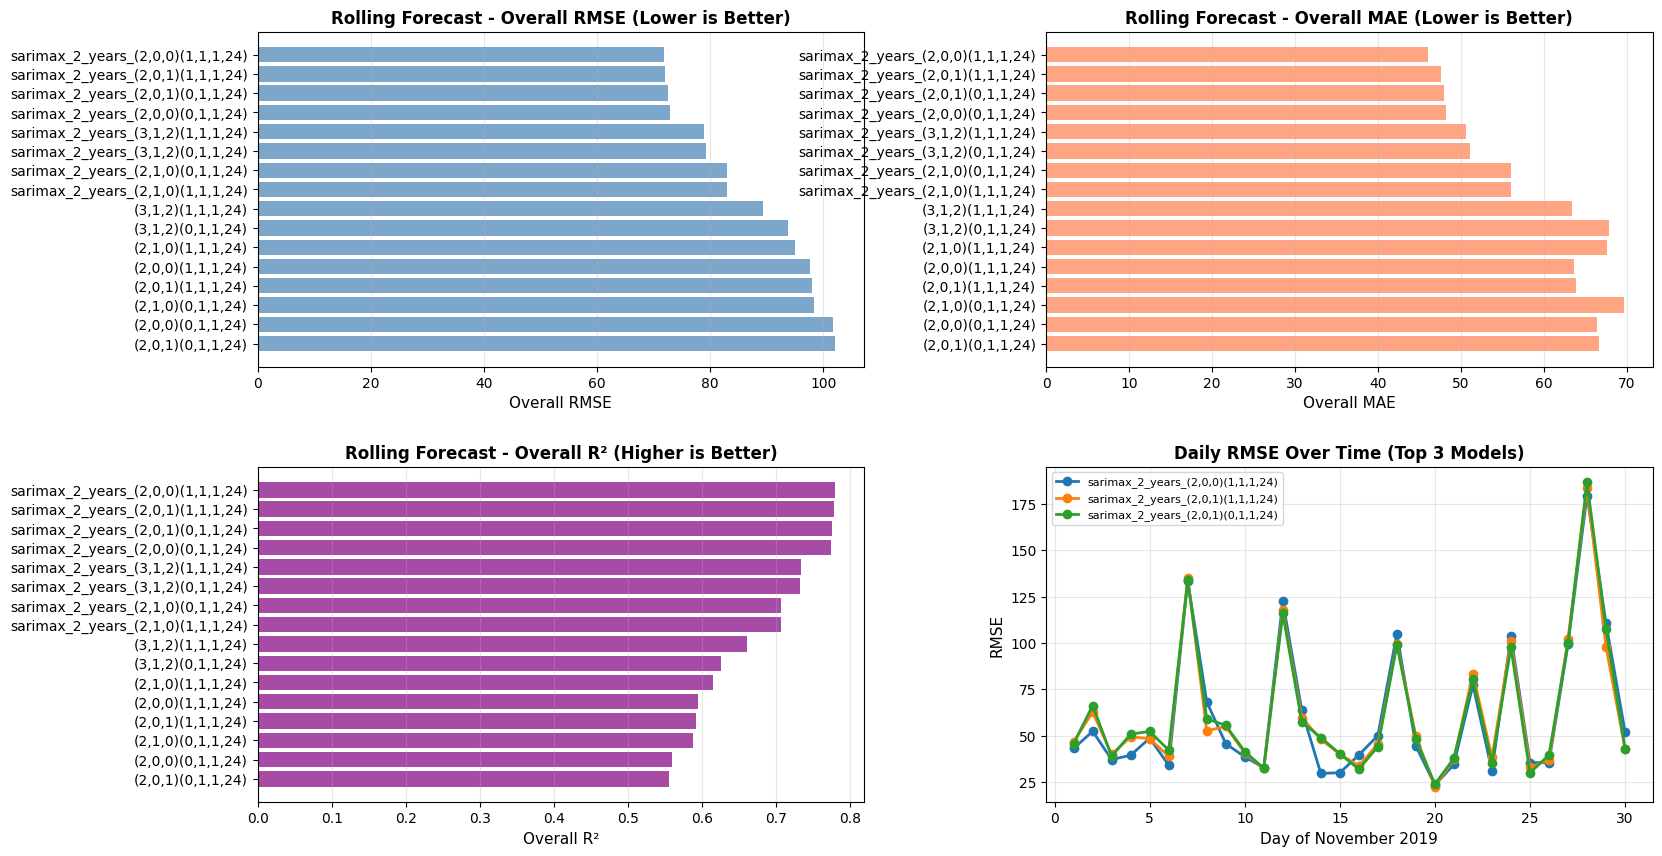


✓ Comparison visualization saved to: models/rolling_forecast_comparison.png

PERFORMANCE STATISTICS

Overall RMSE: min=71.85, max=102.08, mean=86.82
Overall MAE:  min=46.01, max=69.62, mean=58.27
Overall MAPE: min=inf%, max=inf%, mean=inf%
Overall R²:   min=0.5563, max=0.7802, mean=0.6739

DAILY PERFORMANCE VARIABILITY

sarimax_2_years_(2,0,0)(1,1,1,24):
  RMSE: std=38.13, min=23.29, max=179.42
  MAPE: std=nan%, min=16.19%, max=inf%

sarimax_2_years_(2,0,1)(1,1,1,24):
  RMSE: std=36.67, min=22.51, max=183.53
  MAPE: std=nan%, min=28.73%, max=inf%

sarimax_2_years_(2,0,1)(0,1,1,24):
  RMSE: std=36.94, min=23.75, max=186.70
  MAPE: std=nan%, min=14.11%, max=inf%


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load rolling forecast results
rolling_results_df = pd.read_csv('models/rolling_forecast_results.csv')

# Separate overall results from daily results
overall_results = rolling_results_df[rolling_results_df['overall_rmse'].notna()].copy()
daily_results = rolling_results_df[rolling_results_df['day'].notna()].copy()

print(f"{'='*80}")
print(f"ROLLING FORECAST EVALUATION - NOVEMBER 2019")
print(f"{'='*80}\n")

if len(overall_results) > 0:
    # Sort by overall RMSE
    overall_results_sorted = overall_results.sort_values('overall_rmse')
    
    print("Overall Performance Across All Days (Sorted by RMSE):")
    print(f"{'='*80}")
    display_cols = ['model_name', 'overall_rmse', 'overall_mae', 'overall_mape', 'overall_r2', 'total_time']
    print(overall_results_sorted[display_cols].to_string(index=False))
    
    # Best models by different metrics
    print(f"\n{'='*80}")
    print(f"BEST MODELS BY METRIC")
    print(f"{'='*80}")
    
    best_rmse = overall_results_sorted.iloc[0]
    best_mae = overall_results.sort_values('overall_mae').iloc[0]
    best_mape = overall_results.sort_values('overall_mape').iloc[0]
    best_r2 = overall_results.sort_values('overall_r2', ascending=False).iloc[0]
    
    print(f"\nBest by Overall RMSE:")
    print(f"  Model: {best_rmse['model_name']}")
    print(f"  RMSE: {best_rmse['overall_rmse']:.2f} | MAE: {best_rmse['overall_mae']:.2f} | MAPE: {best_rmse['overall_mape']:.2f}% | R²: {best_rmse['overall_r2']:.4f}")
    
    print(f"\nBest by Overall MAE:")
    print(f"  Model: {best_mae['model_name']}")
    print(f"  RMSE: {best_mae['overall_rmse']:.2f} | MAE: {best_mae['overall_mae']:.2f} | MAPE: {best_mae['overall_mape']:.2f}% | R²: {best_mae['overall_r2']:.4f}")
    
    print(f"\nBest by Overall MAPE:")
    print(f"  Model: {best_mape['model_name']}")
    print(f"  RMSE: {best_mape['overall_rmse']:.2f} | MAE: {best_mape['overall_mae']:.2f} | MAPE: {best_mape['overall_mape']:.2f}% | R²: {best_mape['overall_r2']:.4f}")
    
    print(f"\nBest by Overall R²:")
    print(f"  Model: {best_r2['model_name']}")
    print(f"  RMSE: {best_r2['overall_rmse']:.2f} | MAE: {best_r2['overall_mae']:.2f} | MAPE: {best_r2['overall_mape']:.2f}% | R²: {best_r2['overall_r2']:.4f}")
    
    # Visualizations
    fig = plt.figure(figsize=(18, 10))
    
    # Create grid for subplots (2 rows, 2 columns, with bottom row spanning full width)
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, height_ratios=[1, 1])
    
    # Overall performance comparison
    models_short = [name.replace('sarima_2_years_', '') for name in overall_results_sorted['model_name']]
    
    # Plot 1: Overall RMSE
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.barh(models_short, overall_results_sorted['overall_rmse'], color='steelblue', alpha=0.7)
    ax1.set_xlabel('Overall RMSE', fontsize=11)
    ax1.set_title('Rolling Forecast - Overall RMSE (Lower is Better)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.invert_yaxis()
    
    # Plot 2: Overall MAE
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.barh(models_short, overall_results_sorted['overall_mae'], color='coral', alpha=0.7)
    ax2.set_xlabel('Overall MAE', fontsize=11)
    ax2.set_title('Rolling Forecast - Overall MAE (Lower is Better)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.invert_yaxis()
    
    # Plot 3: Overall R²
    ax3 = fig.add_subplot(gs[1, 0])
    r2_sorted = overall_results.sort_values('overall_r2', ascending=False)
    models_short_r2 = [name.replace('sarima_2_years_', '') for name in r2_sorted['model_name']]
    ax3.barh(models_short_r2, r2_sorted['overall_r2'], color='purple', alpha=0.7)
    ax3.set_xlabel('Overall R²', fontsize=11)
    ax3.set_title('Rolling Forecast - Overall R² (Higher is Better)', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    ax3.invert_yaxis()
    
    # Plot 4: Daily performance over time for top 3 models
    if len(daily_results) > 0:
        top_3_models = overall_results_sorted.head(3)['model_name'].values
        
        # Daily RMSE over time
        ax4 = fig.add_subplot(gs[1, 1])
        for model in top_3_models:
            model_daily = daily_results[daily_results['model_name'] == model].sort_values('day')
            model_short = model.replace('sarima_2_years_', '')
            ax4.plot(model_daily['day'], model_daily['rmse'], marker='o', label=model_short, linewidth=2)
        ax4.set_xlabel('Day of November 2019', fontsize=11)
        ax4.set_ylabel('RMSE', fontsize=11)
        ax4.set_title('Daily RMSE Over Time (Top 3 Models)', fontsize=12, fontweight='bold')
        ax4.legend(fontsize=8, loc='best')
        ax4.grid(True, alpha=0.3)
    
    plt.savefig('models/rolling_forecast_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Comparison visualization saved to: models/rolling_forecast_comparison.png")
    
    # Statistics
    print(f"\n{'='*80}")
    print(f"PERFORMANCE STATISTICS")
    print(f"{'='*80}")
    print(f"\nOverall RMSE: min={overall_results['overall_rmse'].min():.2f}, max={overall_results['overall_rmse'].max():.2f}, mean={overall_results['overall_rmse'].mean():.2f}")
    print(f"Overall MAE:  min={overall_results['overall_mae'].min():.2f}, max={overall_results['overall_mae'].max():.2f}, mean={overall_results['overall_mae'].mean():.2f}")
    print(f"Overall MAPE: min={overall_results['overall_mape'].min():.2f}%, max={overall_results['overall_mape'].max():.2f}%, mean={overall_results['overall_mape'].mean():.2f}%")
    print(f"Overall R²:   min={overall_results['overall_r2'].min():.4f}, max={overall_results['overall_r2'].max():.4f}, mean={overall_results['overall_r2'].mean():.4f}")
    
    # Daily variability analysis
    if len(daily_results) > 0:
        print(f"\n{'='*80}")
        print(f"DAILY PERFORMANCE VARIABILITY")
        print(f"{'='*80}")
        
        for model in top_3_models:
            model_daily = daily_results[daily_results['model_name'] == model]
            model_short = model.replace('sarima_2_years_', '')
            print(f"\n{model_short}:")
            print(f"  RMSE: std={model_daily['rmse'].std():.2f}, min={model_daily['rmse'].min():.2f}, max={model_daily['rmse'].max():.2f}")
            print(f"  MAPE: std={model_daily['mape'].std():.2f}%, min={model_daily['mape'].min():.2f}%, max={model_daily['mape'].max():.2f}%")
    
else:
    print("No successful rolling forecasts to evaluate.")


In [20]:
# Analyze the most challenging dates for the best model
best_model_name = overall_results_sorted.iloc[0]['model_name']
best_model_daily = daily_results[daily_results['model_name'] == best_model_name].copy()

# Sort by RMSE to find the worst performing days
worst_days = best_model_daily.sort_values('rmse', ascending=False).head(5)

print(f"{'='*80}")
print(f"5 MOST CHALLENGING DATES FOR BEST MODEL: {best_model_name.replace('sarima_2_years_', '')}")
print(f"{'='*80}\n")

print("Top 5 dates with highest RMSE:")
print(f"{'Rank':<6} {'Date':<12} {'Day':<5} {'RMSE':<10} {'MAE':<10} {'R²':<10}")
print(f"{'-'*60}")

for idx, (_, row) in enumerate(worst_days.iterrows(), 1):
    print(f"{idx:<6} {row['date']:<12} {int(row['day']):<5} {row['rmse']:<10.2f} {row['mae']:<10.2f} {row['r2']:<10.4f}")

print(f"\n{'='*80}")
print(f"ANALYSIS")
print(f"{'='*80}")
print(f"Average RMSE across all days: {best_model_daily['rmse'].mean():.2f}")
print(f"RMSE std deviation: {best_model_daily['rmse'].std():.2f}")
print(f"\nWorst day RMSE is {worst_days.iloc[0]['rmse'] / best_model_daily['rmse'].mean():.1f}x the average")

5 MOST CHALLENGING DATES FOR BEST MODEL: sarimax_2_years_(2,0,0)(1,1,1,24)

Top 5 dates with highest RMSE:
Rank   Date         Day   RMSE       MAE        R²        
------------------------------------------------------------
1      2019-11-28   28    179.42     135.13     -26.9394  
2      2019-11-07   7     133.51     73.96      0.2800    
3      2019-11-12   12    122.34     90.02      -0.5591   
4      2019-11-29   29    110.54     80.67      -2.4759   
5      2019-11-18   18    104.98     82.66      -0.0357   

ANALYSIS
Average RMSE across all days: 61.30
RMSE std deviation: 38.13

Worst day RMSE is 2.9x the average


# Single day for SARIMAX

(24, 41)
Forecasting first day of validation set: 2019-11-01
Time range: 2019-11-01 00:00:00 to 2019-11-01 23:00:00
['arima_results', 'sarima_results', <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x139aaa210>]

Evaluating: SARIMAX(3,1,2)x(0,1,1,24) + Exog
['arima_results', 'sarima_results', <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x139aaa210>]

Evaluating: SARIMAX(3,1,2)x(0,1,1,24) + Exog

First Day Forecast Performance:
MSE:  2214.81
RMSE: 47.06
MAE:  39.98
MAPE: 58.12%
R²:   0.9401

Detailed hourly comparison:
               Hour  Actual  Predicted      Error  Abs_Error   Pct_Error
2019-11-01 00:00:00      55 129.451606 -74.451606  74.451606 -135.366556
2019-11-01 01:00:00      30  82.546853 -52.546853  52.546853 -175.156177
2019-11-01 02:00:00      24  51.416936 -27.416936  27.416936 -114.237234
2019-11-01 03:00:00       6  34.313215 -28.313215  28.313215 -471.886911
2019-11-01 04:00:00      11  27.839902 -16.839902  16.839902 -153

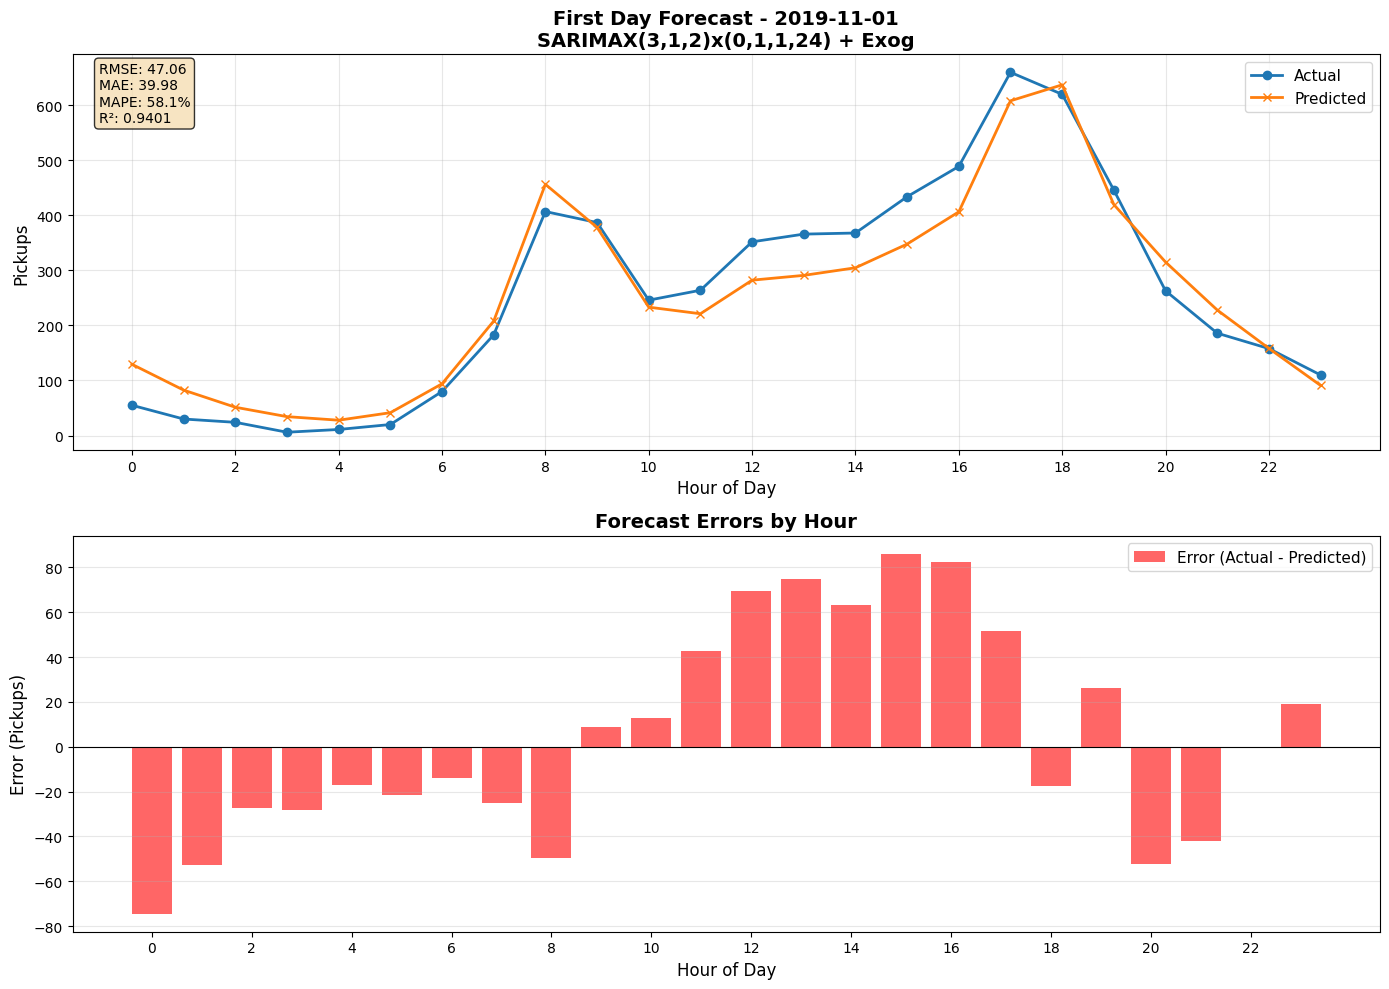


Summary Statistics:
  Average actual pickups: 256.88
  Average predicted pickups: 252.04
  Max overestimate: -74.45 pickups at hour 0
  Max underestimate: 86.07 pickups at hour 15


In [20]:
import pickle

# Forecast the first day of the validation set (24 hours)
# Get the first day's actual values
first_day = val_ts.iloc[:24]
first_day_exog = exog_val.iloc[:24]
print(first_day_exog.shape)
first_day_date = first_day.index[0].date()

print(f"Forecasting first day of validation set: {first_day_date}")
print(f"Time range: {first_day.index[0]} to {first_day.index[-1]}")

# with open("arima_2years", "rb") as f:
#     arima_results = pickle.load(f)

# with open("sarima_2years", "rb") as f:
#     sarima_results = pickle.load(f)

sarimax_path = "sarimax_2years"
sarimax_path = "sarimax_2years_3_1_2"
with open(sarimax_path, "rb") as f:
    sarimax_results = pickle.load(f)

results = ["arima_results", "sarima_results", sarimax_results]


print(results)

model_names = ['ARIMA(0,0,0)', 'SARIMA(3,1,2)x(0,1,1,24)', 'SARIMAX(3,1,2)x(0,1,1,24) + Exog']

# for idx, result in enumerate(results):

idx = 2

result = sarimax_results

model_name = model_names[idx]
print(f"\n{'='*70}")
print(f"Evaluating: {model_name}")
print(f"{'='*70}")

# Use the fitted model to forecast 24 hours
# Only SARIMAX (last model) needs exogenous features
if idx == 2:  # SARIMAX with exog
    forecast_first_day = result.forecast(steps=24, exog=first_day_exog)
else:  # ARIMA and SARIMA without exog
    forecast_first_day = result.forecast(steps=24)

# Calculate errors
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
actual = first_day.values
predicted = forecast_first_day.values

mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
r2 = r2_score(actual, predicted)

print(f"\nFirst Day Forecast Performance:")
print(f"{'='*50}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")
print(f"{'='*50}")

# Create a detailed comparison table
comparison_df = pd.DataFrame({
    'Hour': first_day.index,
    'Actual': actual,
    'Predicted': predicted,
    'Error': actual - predicted,
    'Abs_Error': np.abs(actual - predicted),
    'Pct_Error': ((actual - predicted) / actual * 100)
})

print(f"\nDetailed hourly comparison:")
print(comparison_df.to_string(index=False))

# Plot actual vs predicted for the first day
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Actual vs Predicted
hours = range(24)
axes[0].plot(hours, actual, marker='o', label='Actual', linewidth=2, markersize=6)
axes[0].plot(hours, predicted, marker='x', label='Predicted', linewidth=2, markersize=6)
axes[0].set_title(f'First Day Forecast - {first_day_date}\n{model_name}', 
                fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Pickups', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))
# Add metrics text box
metrics_text = f'RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.1f}%\nR²: {r2:.4f}'
axes[0].text(0.02, 0.98, metrics_text,
            transform=axes[0].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10)

# Plot 2: Errors
axes[1].bar(hours, actual - predicted, color='red', alpha=0.6, label='Error (Actual - Predicted)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_title('Forecast Errors by Hour', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Error (Pickups)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print(f"\nSummary Statistics:")
print(f"  Average actual pickups: {actual.mean():.2f}")
print(f"  Average predicted pickups: {predicted.mean():.2f}")

print(f"  Max overestimate: {(actual - predicted).min():.2f} pickups at hour {(actual - predicted).argmin()}")
print(f"  Max underestimate: {(actual - predicted).max():.2f} pickups at hour {(actual - predicted).argmax()}")

## Extended Validation: Dynamic Rolling Forecast

Testing the model's forecasting capability across the entire validation period (Nov-Dec 2018) using **dynamic forecasting**. 

This approach:
- Forecasts 24 hours ahead for each day
- Updates the model's internal state with actual observations after each day
- Does NOT retrain the model (uses `.append()` method)
- Much faster than full retraining (~60 seconds vs 15+ minutes)
- Provides realistic multi-step ahead forecasts

# Forecast multiple SARIMAX

Forecasting all days in validation period: Nov-Dec 2018 (Dynamic Forecast)
Validation period: 2019-11-01 00:00:00 to 2019-12-31 23:00:00
Total hours: 1464
Total days: 61.0

Using dynamic forecasting: updates state with observations, no retraining

Evaluating: SARIMAX(3,1,2)x(0,1,1,24) + Exog

Evaluating: SARIMAX(3,1,2)x(0,1,1,24) + Exog
  Day 1/30 (2019-11-01): RMSE=47.06, MAE=39.98, R2=0.9401
  Day 1/30 (2019-11-01): RMSE=47.06, MAE=39.98, R2=0.9401
  Day 2/30 (2019-11-02): RMSE=48.58, MAE=36.86, R2=0.9209
  Day 2/30 (2019-11-02): RMSE=48.58, MAE=36.86, R2=0.9209
  Day 3/30 (2019-11-03): RMSE=66.04, MAE=56.84, R2=0.7738
  Day 3/30 (2019-11-03): RMSE=66.04, MAE=56.84, R2=0.7738
  Day 4/30 (2019-11-04): RMSE=21.39, MAE=16.41, R2=0.9875
  Day 4/30 (2019-11-04): RMSE=21.39, MAE=16.41, R2=0.9875
  Day 5/30 (2019-11-05): RMSE=32.95, MAE=27.72, R2=0.9729
  Day 5/30 (2019-11-05): RMSE=32.95, MAE=27.72, R2=0.9729
  Day 6/30 (2019-11-06): RMSE=27.77, MAE=20.51, R2=0.9799
  Day 6/30 (2019-11-06)

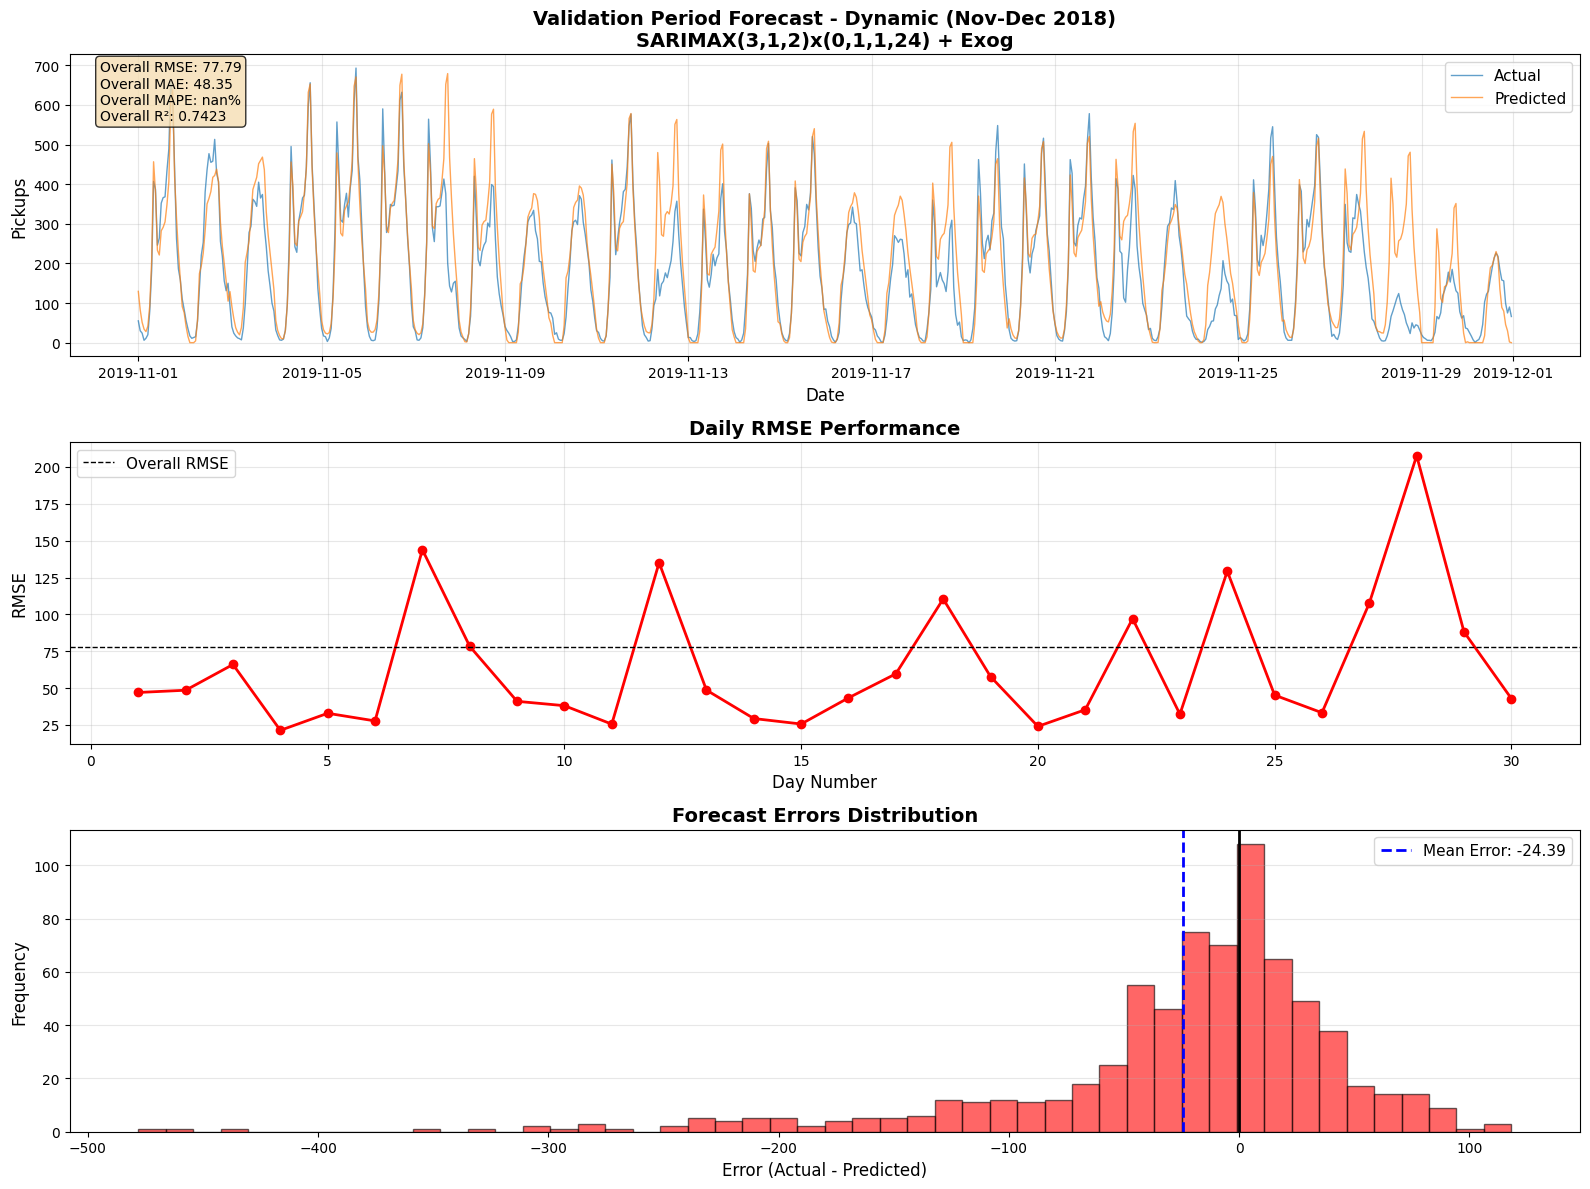


Error Statistics:
  Mean Error: -24.39
  Std Error: 73.86
  Min Error (max overestimate): -478.06
  Max Error (max underestimate): 118.28

Daily metrics saved to: model_test/sarimax_2years_3_1_2_daily_metrics.csv
Overall statistics saved to: model_test/sarimax_2years_3_1_2_overall_stats.csv


In [22]:
# Forecast all days in validation period (Nov-Dec) using dynamic rolling forecasts
# This approach updates the model's state with actual observations but does NOT retrain
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"Forecasting all days in validation period: Nov-Dec 2018 (Dynamic Forecast)")
print(f"Validation period: {val_ts.index[0]} to {val_ts.index[-1]}")
print(f"Total hours: {len(val_ts)}")
print(f"Total days: {len(val_ts) / 24:.1f}")
print("\nUsing dynamic forecasting: updates state with observations, no retraining")

model_names = ['ARIMA(0,0,0)', 'SARIMA(3,1,2)x(0,1,1,24)', 'SARIMAX(3,1,2)x(0,1,1,24) + Exog']


model_path = "sarimax_2years_3_1_2"
with open(model_path, "rb") as f:
    sarimax_results = pickle.load(f)

results = ["placeholder", "placerholder2", sarimax_results]

idx = 2

model_name = model_names[idx]

# # extract model name form loaded model
# model_name = sarimax_results.model_orders

print(f"\n{'='*70}")
print(f"Evaluating: {model_name}")
print(f"{'='*70}")

# Store all predictions and metrics per day
all_predictions = []
all_actuals = []
daily_metrics = []

# Forecast 24 hours at a time (one day at a time) using dynamic forecasting
num_days = int(np.ceil(len(val_ts) / 24)) - 31

# Start with the fitted model - use results[2] for SARIMAX
current_model = results[idx]

for day_num in range(num_days):
    # Get the day's data
    start_idx = day_num * 24
    end_idx = min(start_idx + 24, len(val_ts))
    
    day_actual = val_ts.iloc[start_idx:end_idx]
    day_exog = exog_val.iloc[start_idx:end_idx]
    day_date = day_actual.index[0].date()
    
    # Forecast this day (24 hours or less for the last day)
    steps = end_idx - start_idx
    
    # Only SARIMAX (idx==2) needs exogenous features
    if idx == 2:
        day_forecast = current_model.forecast(steps=steps, exog=day_exog)
    else:
        day_forecast = current_model.forecast(steps=steps)
    
    # Ensure forecasts are non-negative (pickups cannot be negative)
    day_forecast = day_forecast.clip(lower=0)

    # Store predictions and actuals
    all_predictions.extend(day_forecast.values)
    all_actuals.extend(day_actual.values)
    
    # Update the model with actual observations (dynamic forecasting)
    # This extends the model's state without retraining
    if day_num < num_days - 1:  # Don't append on the last iteration
        if idx == 2:  # SARIMAX with exogenous
            current_model = current_model.append(day_actual, exog=day_exog, refit=False)
        else:  # ARIMA and SARIMA without exogenous
            current_model = current_model.append(day_actual, refit=False)
    
    # Calculate metrics for this day
    day_mse = mean_squared_error(day_actual.values, day_forecast.values)
    day_rmse = np.sqrt(day_mse)
    day_mae = mean_absolute_error(day_actual.values, day_forecast.values)
    day_mape = np.mean(np.abs((day_actual.values - day_forecast.values) / day_actual.values)) * 100
    day_r2 = r2_score(day_actual.values, day_forecast.values)

    
    daily_metrics.append({
        'date': day_date,
        'day_num': day_num + 1,
        'hours': steps,
        'rmse': day_rmse,
        'mae': day_mae,
        'mape': day_mape,
        'r2': day_r2,
        'mean_actual': day_actual.mean(),
        'mean_predicted': day_forecast.mean()
    })
    
    print(f"  Day {day_num + 1}/{num_days} ({day_date}): RMSE={day_rmse:.2f}, MAE={day_mae:.2f}, R2={day_r2:.4f}")

# Convert to arrays
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Calculate overall metrics across all validation days
overall_mse = mean_squared_error(all_actuals, all_predictions)
overall_rmse = np.sqrt(overall_mse)
overall_mae = mean_absolute_error(all_actuals, all_predictions)
overall_mape = np.mean(np.abs((all_actuals - all_predictions) / all_actuals)) * 100
overall_r2 = r2_score(all_actuals, all_predictions)

print(f"\n{'='*70}")
print(f"OVERALL VALIDATION PERFORMANCE (All Nov-Dec Days)")
print(f"{'='*70}")
print(f"MSE:  {overall_mse:.2f}")
print(f"RMSE: {overall_rmse:.2f}")
print(f"MAE:  {overall_mae:.2f}")
print(f"MAPE: {overall_mape:.2f}%")
print(f"R²:   {overall_r2:.4f}")
print(f"{'='*70}")

# Create daily metrics dataframe
daily_metrics_df = pd.DataFrame(daily_metrics)

print(f"\nDaily Performance Summary:")
print(daily_metrics_df.to_string(index=False))

print(f"\nDaily Metrics Statistics:")
print(f"  Average Daily RMSE: {daily_metrics_df['rmse'].mean():.2f} ± {daily_metrics_df['rmse'].std():.2f}")
print(f"  Average Daily MAE:  {daily_metrics_df['mae'].mean():.2f} ± {daily_metrics_df['mae'].std():.2f}")
print(f"  Best Day (lowest RMSE): Day {daily_metrics_df.loc[daily_metrics_df['rmse'].idxmin(), 'day_num']} ({daily_metrics_df.loc[daily_metrics_df['rmse'].idxmin(), 'date']}), RMSE={daily_metrics_df['rmse'].min():.2f}")
print(f"  Worst Day (highest RMSE): Day {daily_metrics_df.loc[daily_metrics_df['rmse'].idxmax(), 'day_num']} ({daily_metrics_df.loc[daily_metrics_df['rmse'].idxmax(), 'date']}), RMSE={daily_metrics_df['rmse'].max():.2f}")

# Plot overall predictions vs actuals
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Full validation period - Actual vs Predicted
axes[0].plot(val_ts[:num_days*24].index, all_actuals, label='Actual', alpha=0.7, linewidth=1)
axes[0].plot(val_ts[:num_days*24].index, all_predictions, label='Predicted', alpha=0.7, linewidth=1)
axes[0].set_title(f'Validation Period Forecast - Dynamic (Nov-Dec 2018)\n{model_name}', 
                fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Pickups', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
metrics_text = f'Overall RMSE: {overall_rmse:.2f}\nOverall MAE: {overall_mae:.2f}\nOverall MAPE: {overall_mape:.1f}%\nOverall R²: {overall_r2:.4f}'
axes[0].text(0.02, 0.98, metrics_text,
            transform=axes[0].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10)

# Plot 2: Daily RMSE over time
axes[1].plot(daily_metrics_df['day_num'], daily_metrics_df['rmse'], 
            marker='o', linewidth=2, markersize=6, color='red')
axes[1].axhline(y=overall_rmse, color='black', linestyle='--', linewidth=1, label='Overall RMSE')
axes[1].set_title('Daily RMSE Performance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day Number', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Plot 3: Errors distribution
errors = all_actuals - all_predictions
axes[2].hist(errors, bins=50, color='red', alpha=0.6, edgecolor='black')
axes[2].axvline(x=0, color='black', linestyle='-', linewidth=2)
axes[2].axvline(x=errors.mean(), color='blue', linestyle='--', linewidth=2, 
                label=f'Mean Error: {errors.mean():.2f}')
axes[2].set_title('Forecast Errors Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Error (Actual - Predicted)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Create model_test directory if it doesn't exist
import os
os.makedirs('model_test', exist_ok=True)

# Extract model name from path for file naming
model_file_name = os.path.basename(model_path)

# Save the plot
plot_filename = f'model_test/{model_file_name}_validation_forecast.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to: {plot_filename}")

plt.show()

print(f"\nError Statistics:")
print(f"  Mean Error: {errors.mean():.2f}")
print(f"  Std Error: {errors.std():.2f}")

print(f"  Min Error (max overestimate): {errors.min():.2f}")
print(f"  Max Error (max underestimate): {errors.max():.2f}")

# Save daily metrics to CSV
daily_stats_filename = f'model_test/{model_file_name}_daily_metrics.csv'
daily_metrics_df.to_csv(daily_stats_filename, index=False)
print(f"\nDaily metrics saved to: {daily_stats_filename}")

# Save overall/average statistics to CSV
overall_stats = {
    'model_path': [model_path],
    'model_name': [model_name],
    'validation_days': [num_days],
    'overall_mse': [overall_mse],
    'overall_rmse': [overall_rmse],
    'overall_mae': [overall_mae],
    'overall_mape': [overall_mape],
    'overall_r2': [overall_r2],
    'avg_daily_rmse': [daily_metrics_df['rmse'].mean()],
    'std_daily_rmse': [daily_metrics_df['rmse'].std()],
    'avg_daily_mae': [daily_metrics_df['mae'].mean()],
    'std_daily_mae': [daily_metrics_df['mae'].std()],
    'avg_daily_mape': [daily_metrics_df['mape'].mean()],
    'std_daily_mape': [daily_metrics_df['mape'].std()],
    'avg_daily_r2': [daily_metrics_df['r2'].mean()],
    'std_daily_r2': [daily_metrics_df['r2'].std()],
    'best_day_rmse': [daily_metrics_df['rmse'].min()],
    'worst_day_rmse': [daily_metrics_df['rmse'].max()],
    'mean_error': [errors.mean()],
    'std_error': [errors.std()],
    'min_error': [errors.min()],
    'max_error': [errors.max()]
}
overall_stats_df = pd.DataFrame(overall_stats)
overall_stats_filename = f'model_test/{model_file_name}_overall_stats.csv'
overall_stats_df.to_csv(overall_stats_filename, index=False)
print(f"Overall statistics saved to: {overall_stats_filename}")

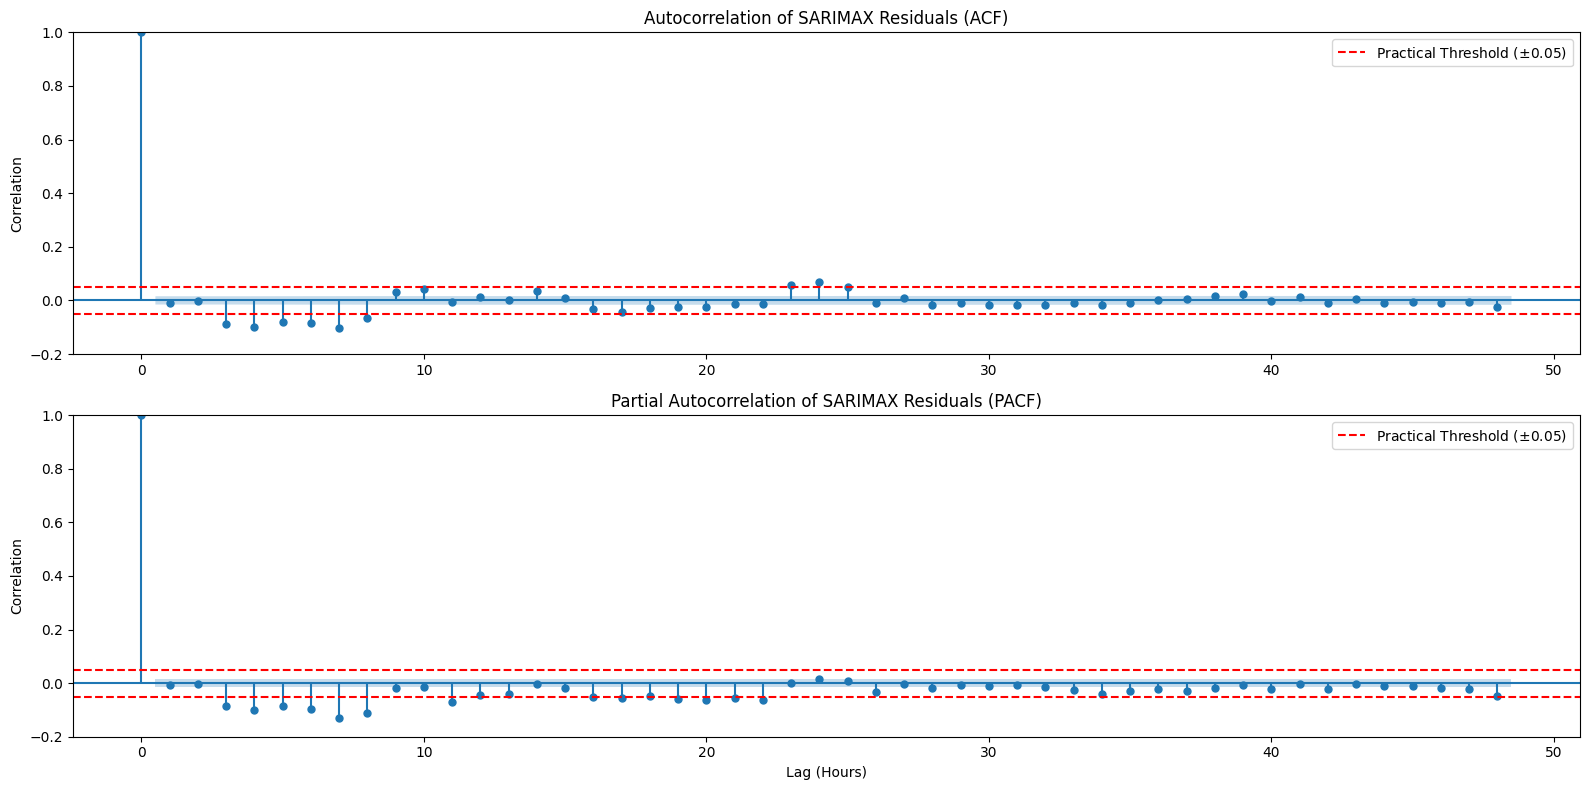

In [131]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assuming 'residuals' contains sarimax_results.resid
# residuals = sarimax_results.resid 

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

residuals = sarimax_results.resid

# --- ACF of Residuals ---
plot_acf(residuals, lags=48, ax=axes[0], title='Autocorrelation of SARIMAX Residuals (ACF)')
axes[0].set_ylabel('Correlation')
axes[0].set_ylim(-0.2, 1.0) # Ensure y-axis covers the new lines

# Add lines for practical significance threshold (+/- 0.05)
axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Practical Threshold ($\pm 0.05$)')
axes[0].axhline(y=-0.05, color='red', linestyle='--', linewidth=1.5)
axes[0].legend(loc='upper right')

# --- PACF of Residuals ---
plot_pacf(residuals, lags=48, ax=axes[1], title='Partial Autocorrelation of SARIMAX Residuals (PACF)')
axes[1].set_xlabel('Lag (Hours)')
axes[1].set_ylabel('Correlation')
axes[1].set_ylim(-0.2, 1.0) # Ensure y-axis covers the new lines

# Add lines for practical significance threshold (+/- 0.05)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Practical Threshold ($\pm 0.05$)')
axes[1].axhline(y=-0.05, color='red', linestyle='--', linewidth=1.5)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Model Comparison by AIC

MODEL COMPARISON BY AIC - Found 16 models

MODEL RANKING BY AIC (Lower is Better):
Rank   Type       Parameters                AIC          BIC         
--------------------------------------------------------------------------------
1      SARIMAX    (2,0,0)(1,1,1,24)         164658.94    165012.25   
2      SARIMAX    (3,1,2)(1,1,1,24)         164877.59    165253.94   
3      SARIMAX    (2,0,1)(1,1,1,24)         164947.48    165308.47   
4      SARIMAX    (3,1,2)(0,1,1,24)         164950.85    165319.52   
5      SARIMAX    (2,0,0)(0,1,1,24)         165018.15    165363.78   
6      SARIMAX    (2,0,1)(0,1,1,24)         165021.88    165375.19   
7      SARIMAX    (2,1,0)(1,1,1,24)         166240.50    166593.81   
8      SARIMAX    (2,1,0)(0,1,1,24)         166339.74    166685.37   
9      SARIMA     (3,1,2)(1,1,1,24)         170672.87    170734.31   
10     SARIMA     (2,0,1)(1,1,1,24)         170766.80    170812.88   
11     SARIMA     (2,0,0)(1,1,1,24)         170789.70    170828.11

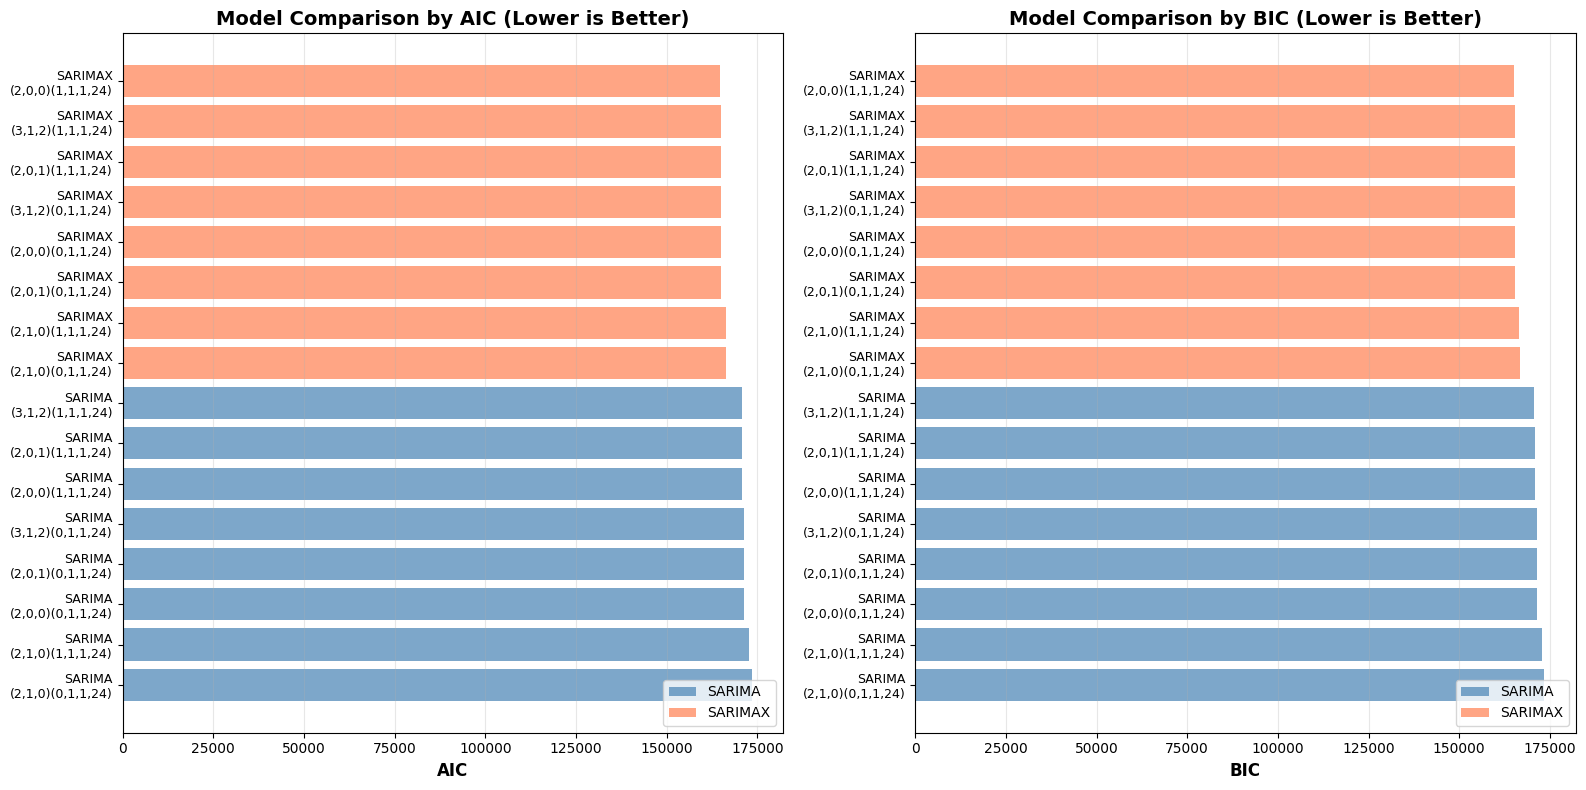


✓ Visualization saved to: models/aic_bic_comparison.png

STATISTICS

AIC Range: 164658.94 to 173421.91
BIC Range: 165012.25 to 173452.64

Average AIC by Model Type:
  SARIMA:  171562.52
  SARIMAX: 165256.89
  Difference: 6305.63 (SARIMAX better)


In [21]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# Load all models from the models folder
models_folder = 'models'
model_files = glob(f'{models_folder}/*sarima*.pkl')

print(f"{'='*80}")
print(f"MODEL COMPARISON BY AIC - Found {len(model_files)} models")
print(f"{'='*80}\n")

# Store evaluation results
aic_comparison = []

for model_file in sorted(model_files):
    model_name = os.path.basename(model_file).replace('.pkl', '')
    
    try:
        # Load the model
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
        
        # Extract model type and parameters
        if 'sarimax' in model_name.lower():
            model_type = 'SARIMAX'
        else:
            model_type = 'SARIMA'
        
        params_str = model_name.replace('sarima_2_years_', '').replace('sarimax_2_years_', '')
        
        # Get AIC and BIC
        aic_data = {
            'model_name': model_name,
            'model_type': model_type,
            'parameters': params_str,
            'aic': model.aic,
            'bic': model.bic,
            'log_likelihood': model.llf
        }
        
        aic_comparison.append(aic_data)
        
    except Exception as e:
        print(f"✗ Failed to load {model_name}: {str(e)}")

# Create comparison DataFrame
aic_df = pd.DataFrame(aic_comparison)

if len(aic_df) > 0:
    # Sort by AIC (lower is better)
    aic_df_sorted = aic_df.sort_values('aic')
    
    print(f"MODEL RANKING BY AIC (Lower is Better):")
    print(f"{'='*80}")
    print(f"{'Rank':<6} {'Type':<10} {'Parameters':<25} {'AIC':<12} {'BIC':<12}")
    print(f"{'-'*80}")
    
    for idx, row in enumerate(aic_df_sorted.iterrows(), 1):
        _, data = row
        print(f"{idx:<6} {data['model_type']:<10} {data['parameters']:<25} {data['aic']:<12.2f} {data['bic']:<12.2f}")
    
    # Best models
    print(f"\n{'='*80}")
    print(f"BEST MODELS")
    print(f"{'='*80}")
    
    best_aic = aic_df_sorted.iloc[0]
    best_bic = aic_df.sort_values('bic').iloc[0]
    
    print(f"\nBest by AIC:")
    print(f"  Model: {best_aic['model_type']} {best_aic['parameters']}")
    print(f"  AIC: {best_aic['aic']:.2f} | BIC: {best_aic['bic']:.2f} | Log-Likelihood: {best_aic['log_likelihood']:.2f}")
    
    print(f"\nBest by BIC:")
    print(f"  Model: {best_bic['model_type']} {best_bic['parameters']}")
    print(f"  AIC: {best_bic['aic']:.2f} | BIC: {best_bic['bic']:.2f} | Log-Likelihood: {best_bic['log_likelihood']:.2f}")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Prepare labels
    labels = [f"{row['model_type']}\n{row['parameters']}" for _, row in aic_df_sorted.iterrows()]
    
    # Plot 1: AIC comparison
    colors = ['steelblue' if t == 'SARIMA' else 'coral' for t in aic_df_sorted['model_type']]
    ax1.barh(range(len(aic_df_sorted)), aic_df_sorted['aic'], color=colors, alpha=0.7)
    ax1.set_yticks(range(len(aic_df_sorted)))
    ax1.set_yticklabels(labels, fontsize=9)
    ax1.set_xlabel('AIC', fontsize=12, fontweight='bold')
    ax1.set_title('Model Comparison by AIC (Lower is Better)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.invert_yaxis()
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='SARIMA'),
                      Patch(facecolor='coral', alpha=0.7, label='SARIMAX')]
    ax1.legend(handles=legend_elements, loc='lower right')
    
    # Plot 2: BIC comparison
    bic_sorted = aic_df.sort_values('bic')
    labels_bic = [f"{row['model_type']}\n{row['parameters']}" for _, row in bic_sorted.iterrows()]
    colors_bic = ['steelblue' if t == 'SARIMA' else 'coral' for t in bic_sorted['model_type']]
    
    ax2.barh(range(len(bic_sorted)), bic_sorted['bic'], color=colors_bic, alpha=0.7)
    ax2.set_yticks(range(len(bic_sorted)))
    ax2.set_yticklabels(labels_bic, fontsize=9)
    ax2.set_xlabel('BIC', fontsize=12, fontweight='bold')
    ax2.set_title('Model Comparison by BIC (Lower is Better)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.invert_yaxis()
    ax2.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('models/aic_bic_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Visualization saved to: models/aic_bic_comparison.png")
    
    # Statistics
    print(f"\n{'='*80}")
    print(f"STATISTICS")
    print(f"{'='*80}")
    print(f"\nAIC Range: {aic_df['aic'].min():.2f} to {aic_df['aic'].max():.2f}")
    print(f"BIC Range: {aic_df['bic'].min():.2f} to {aic_df['bic'].max():.2f}")
    
    # Compare SARIMA vs SARIMAX
    if 'SARIMA' in aic_df['model_type'].values and 'SARIMAX' in aic_df['model_type'].values:
        sarima_avg_aic = aic_df[aic_df['model_type'] == 'SARIMA']['aic'].mean()
        sarimax_avg_aic = aic_df[aic_df['model_type'] == 'SARIMAX']['aic'].mean()
        
        print(f"\nAverage AIC by Model Type:")
        print(f"  SARIMA:  {sarima_avg_aic:.2f}")
        print(f"  SARIMAX: {sarimax_avg_aic:.2f}")
        print(f"  Difference: {abs(sarima_avg_aic - sarimax_avg_aic):.2f} ({('SARIMAX better' if sarimax_avg_aic < sarima_avg_aic else 'SARIMA better')})")
    
else:
    print("\nNo models found to compare.")